## 0. Load Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. 1차 데이터 전처리

In [7]:
df = pd.read_csv('data/FAF5.7.1_2018-2024_half.csv')

In [8]:
df.head()

,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,dist_band,...,current_value_2022,current_value_2023,current_value_2024,tmiles_2018,tmiles_2019,tmiles_2020,tmiles_2021,tmiles_2022,tmiles_2023,tmiles_2024
0,NaN,11,11,NaN,NaN,1,NaN,1,1,1,...,101.069223,104.272629,115.502844,3.218410,3.351765,3.375547,3.482383,3.502040,3.469055,3.474500
1,NaN,11,19,NaN,NaN,1,NaN,1,1,2,...,764.053625,788.270430,873.167561,48.631191,50.646235,51.005589,52.619906,52.916934,52.418516,52.500796
2,NaN,11,129,NaN,NaN,1,NaN,1,1,3,...,2.695525,2.780960,3.080471,0.450066,0.468714,0.472040,0.486980,0.489729,0.485116,0.485878
3,NaN,11,131,NaN,NaN,1,NaN,1,1,2,...,24.746343,25.530683,28.280351,2.177036,2.267241,2.283328,2.355595,2.368892,2.346580,2.350263
4,NaN,11,139,NaN,NaN,1,NaN,1,1,2,...,10.173100,10.495538,11.625913,1.274964,1.327792,1.337213,1.379536,1.387323,1.374256,1.376413


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2475280 entries, 0 to 2475279
Data columns (total 38 columns):
 #   Column              Dtype  
---  ------              -----  
 0   fr_orig             float64
 1   dms_orig            int64  
 2   dms_dest            int64  
 3   fr_dest             float64
 4   fr_inmode           float64
 5   dms_mode            int64  
 6   fr_outmode          float64
 7   sctg2               int64  
 8   trade_type          int64  
 9   dist_band           int64  
 10  tons_2018           float64
 11  tons_2019           float64
 12  tons_2020           float64
 13  tons_2021           float64
 14  tons_2022           float64
 15  tons_2023           float64
 16  tons_2024           float64
 17  value_2018          float64
 18  value_2019          float64
 19  value_2020          float64
 20  value_2021          float64
 21  value_2022          float64
 22  value_2023          float64
 23  value_2024          float64
 24  current_value_2018  floa

In [10]:
df.isna().sum()

fr_orig               1469102
dms_orig                    0
dms_dest                    0
fr_dest               1524891
fr_inmode             1469102
dms_mode                    0
fr_outmode            1524891
sctg2                       0
trade_type                  0
dist_band                   0
tons_2018                   0
tons_2019                   0
tons_2020                   0
tons_2021                   0
tons_2022                   0
tons_2023                   0
tons_2024                   0
value_2018                  0
value_2019                  0
value_2020                  0
value_2021                  0
value_2022                  0
value_2023                  0
value_2024                  0
current_value_2018          0
current_value_2019          0
current_value_2020          0
current_value_2021          0
current_value_2022          0
current_value_2023          0
current_value_2024          0
tmiles_2018                 0
tmiles_2019                 0
tmiles_202

- 전체 데이터를 확인했을 때 fr_orig, fr_dest 등 해외 수입/수출 여부에 대해서만 NA가 존재한다.

- 또한, tons, value, current_value, tmiles와 같은 변수들은 0이 기록되어 있을 가능성이 있어 EDA과정에서 0을 어떻게 처리해야 할지 간단하게 분석을 수행하였다.

#### 1.1 주요 지표 0값에 대한 해석 및 처리

In [15]:
# 1. 연도 목록 추출
years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]

# 2. 고정 컬럼
id_cols = [
    "dms_orig", "dms_dest",
    "fr_orig", "fr_dest",
    "dms_mode", "fr_inmode", "fr_outmode",
    "sctg2",
    "trade_type",
    "dist_band"
]

# 3. long 포맷용 데이터 생성
dfs = []

for y in years:
    temp = df[id_cols].copy()
    temp["year"] = y
    temp["tons"] = df[f"tons_{y}"]
    temp["value"] = df.get(f"value_{y}")
    temp["current_value"] = df.get(f"current_value_{y}")
    temp["tmiles"] = df.get(f"tmiles_{y}")
    dfs.append(temp)

df_long = pd.concat(dfs, ignore_index=True)
print(df_long.shape)

(17326960, 15)


In [16]:
# 전체 컬럼 중 음수 데이터 확인
cols = [col for col in df_long.columns] 

print("--- 컬럼별 음수 데이터 개수 ---")
print((df_long[cols] < 0).sum())

--- 컬럼별 음수 데이터 개수 ---
dms_orig         0
dms_dest         0
fr_orig          0
fr_dest          0
dms_mode         0
fr_inmode        0
fr_outmode       0
sctg2            0
trade_type       0
dist_band        0
year             0
tons             0
value            0
current_value    0
tmiles           0
dtype: int64


In [17]:
tons_0 = df_long.loc[(df_long['tons'] == 0),['tons','value','current_value','tmiles']].apply(sum)

print(tons_0)

tons_0_df = df_long.loc[(df_long['tons'] == 0)]
len(tons_0_df)

tons              0.000000
value            30.759039
current_value    35.249362
tmiles            0.001731
dtype: float64


5580580

음수 데이터는 없고, ton이 0인 경우를 확인했을 때 꽤나 많은 데이터가 포함이 되었다.

In [18]:
tons_0_df['dist_band'].value_counts()

dist_band
8    1115830
6     985003
3     791891
4     736781
5     707630
7     637250
2     427987
1     178208
Name: count, dtype: int64

평균 가중 거리 구간(dist band : sum(거리 * 물동량) / sum(물동량))이 ton이 0임에도 가장 높은 구간에 대부분 포함되었다.

-> 해외 수입/수출이 주를 이루지 않을까? 라고 생각

In [19]:
# 항공 / 트럭 / 기차 / 배 / 메일?소포?
tons_0_df['dms_mode'].value_counts()

dms_mode
4    2260427
1    1205077
2    1029447
5     863147
3     123996
7      93791
6       4382
8        313
Name: count, dtype: int64

동일하게, 항공인 경우가 대부분 -> ton이 0인 데이터들의 구성이 주로 해외 데이터로 구성되어있나?

In [20]:
print(tons_0_df['fr_orig'].notna().sum() + tons_0_df['fr_dest'].notna().sum())

print(len(tons_0_df))

5580580
5580580


ton이 0인 데이터는 모두 해외 수입/수출로 구성되어 있다.

In [21]:
value_0 = df_long.loc[(df_long['value'] == 0),['tons','value','current_value','tmiles']].apply(sum)
print(value_0)

value_0_df = df_long.loc[(df_long['value'] == 0)]
value_0_df.head()

tons             287922.006766
value                 0.000000
current_value         0.000000
tmiles            45904.267380
dtype: float64


,dms_orig,dms_dest,fr_orig,fr_dest,dms_mode,fr_inmode,fr_outmode,sctg2,trade_type,dist_band,year,tons,value,current_value,tmiles
489039,19,61,NaN,NaN,1,NaN,NaN,41,1,8,2018,0.000571,0.0,0.0,0.001178
489041,19,182,NaN,NaN,1,NaN,NaN,41,1,4,2018,0.441184,0.0,0.0,0.234156
489058,19,472,NaN,NaN,1,NaN,NaN,41,1,2,2018,0.678083,0.0,0.0,0.143038
489062,20,20,NaN,NaN,3,NaN,NaN,41,1,4,2018,6.641458,0.0,0.0,3.353718
489065,20,531,NaN,NaN,3,NaN,NaN,41,1,5,2018,60.498798,0.0,0.0,52.843274


In [ ]:
# 해외 데이터 길이 / 전체 데이터 길이 (99.97% 가량 해외 데이터)
print( (value_0_df['fr_orig'].notna().sum() + value_0_df['fr_dest'].notna().sum()) / len(value_0_df) )

0.9997991035714363


In [23]:
current_value_0 = df_long.loc[(df_long['current_value'] == 0),['tons','value','current_value','tmiles']].apply(sum)
print(current_value_0)

current_value_0_df = df_long.loc[(df_long['current_value'] == 0)]
current_value_0_df.head()

tons             287922.006766
value                 0.000000
current_value         0.000000
tmiles            45904.267380
dtype: float64


,dms_orig,dms_dest,fr_orig,fr_dest,dms_mode,fr_inmode,fr_outmode,sctg2,trade_type,dist_band,year,tons,value,current_value,tmiles
489039,19,61,NaN,NaN,1,NaN,NaN,41,1,8,2018,0.000571,0.0,0.0,0.001178
489041,19,182,NaN,NaN,1,NaN,NaN,41,1,4,2018,0.441184,0.0,0.0,0.234156
489058,19,472,NaN,NaN,1,NaN,NaN,41,1,2,2018,0.678083,0.0,0.0,0.143038
489062,20,20,NaN,NaN,3,NaN,NaN,41,1,4,2018,6.641458,0.0,0.0,3.353718
489065,20,531,NaN,NaN,3,NaN,NaN,41,1,5,2018,60.498798,0.0,0.0,52.843274


In [24]:
print( (current_value_0_df['fr_orig'].notna().sum() + current_value_0_df['fr_dest'].notna().sum()) / len(current_value_0_df) )

0.9997991035714363


In [25]:
tmiles_0 = df_long.loc[(df_long['tmiles'] == 0),['tons','value','current_value','tmiles']].apply(sum)
print(tmiles_0)

tmiles_0_df = df_long.loc[(df_long['tmiles'] == 0)]
tmiles_0_df.head()

tons             893439.439205
value            300213.334175
current_value    403754.626989
tmiles                0.000000
dtype: float64


,dms_orig,dms_dest,fr_orig,fr_dest,dms_mode,fr_inmode,fr_outmode,sctg2,trade_type,dist_band,year,tons,value,current_value,tmiles
413847,111,111,NaN,NaN,5,NaN,NaN,38,1,1,2018,0.00006,0.028537,0.028919,0.0
435727,111,111,NaN,NaN,5,NaN,NaN,39,1,1,2018,0.00005,0.008678,0.008941,0.0
518714,20,20,801.0,NaN,5,5.0,NaN,1,2,6,2018,0.00000,0.000000,0.000000,0.0
518721,61,121,801.0,NaN,5,5.0,NaN,1,2,8,2018,0.00000,0.000000,0.000000,0.0
518722,61,122,801.0,NaN,5,5.0,NaN,1,2,8,2018,0.00000,0.000000,0.000000,0.0


In [26]:
print( (tmiles_0_df['fr_orig'].notna().sum() + tmiles_0_df['fr_dest'].notna().sum()) / len(tmiles_0_df) )

0.9999974980963193


같은 과정을 value, current_value, tmiles에 대해서 반복했을 때, 거의 대부분의 경우 해외 물류로 구성.

그러면, 분석 프로세스를

1. 데이터를 국내 / 수입 / 수출로 나눈다.

2. 국내 전체 흐름을 Tons, values 분석하고, 주요 생산지/소비지(?)를 파악한다.

* 유의사항 (주로 sum을 기준으로 흐름을 파악할 것이기에, 앞서 소수의 0은 우선 포함하되, value / tons와 같은 파생 변수 생성 시 zero division 에러가 날 수 있음에 유의)

    2.1 도출 결과로 운송 수단이나 다른 추가 분석을 진행할 수 있으면 하고

3. 그 뒤 해외 수입/수출에 대해 분석한다.

    3.1 그 과정에서 0에 대한 처리는 2차 데이터 전처리에서 다시 진행해보자.

#### 1.2 기존 데이터 국내 / 수입 / 수출로 분리 및 EDA를 위한 메타 데이터 결합

메타 데이터 결합을 통해 코드를 그에 맞는 이름으로 변환하고, _nm을 붙여 시각화에 용이하게끔 데이터 재구성

In [126]:
df = pd.read_csv('data/FAF5.7.1_2018-2024_half.csv')

# 메타 데이터 병합
file_str = 'data/FAF5_metadata.xlsx'
mode = pd.read_excel(file_str, sheet_name="Mode").rename(
    columns={"Numeric Label":"code","Description":"mode_name"})
trade = pd.read_excel(file_str, sheet_name="Trade Type").rename(
    columns={"Numeric Label":"code","Description":"trade_type_nm"})
dist = pd.read_excel(file_str, sheet_name="Distance Band").rename(
    columns={"Numeric Label":"code","Description":"dist_band_nm"})
sctg = pd.read_excel(file_str, sheet_name="Commodity (SCTG2)").rename(
    columns={"Numeric Label":"code","Description":"sctg2_name"})
state = pd.read_excel(file_str, sheet_name="State").rename(
    columns={"Numeric Label":"code","Description":"state_name"})
domestic = pd.read_excel(file_str, sheet_name="FAF Zone (Domestic)").rename(
    columns={"Numeric Label":"code","Short Description":"dms_name"})
foreign = pd.read_excel(file_str, sheet_name="FAF Zone (Foreign)").rename(
    columns={"Numeric Label":"code","Description":"fr_name"})

In [127]:
# 운송 모드 변환 (dms_mode, fr_inmode, fr_outmode)
df = df.merge(mode[["code","mode_name"]].rename(columns = {'mode_name':'dms_mode_nm'}), 
        left_on="dms_mode", right_on="code", how="left").drop(columns="code")
df = df.merge(mode[["code","mode_name"]].rename(columns = {'mode_name':'fr_inmode_nm'}), 
        left_on="fr_inmode", right_on="code", how="left").drop(columns="code")
df = df.merge(mode[["code","mode_name"]].rename(columns = {'mode_name':'fr_outmode_nm'}), 
        left_on="fr_outmode", right_on="code", how="left").drop(columns="code")

# trade 변환
df = df.merge(trade[["code","trade_type_nm"]], 
        left_on="trade_type", right_on="code", how="left").drop(columns="code")

# dist 변환
df = df.merge(dist[["code","dist_band_nm"]], 
        left_on="dist_band", right_on="code", how="left").drop(columns="code")

# sctg 변환
# (요기만 name으로 처리했습니다! 큰 이유는 없긴한데... 귀찮으니 그냥 하시죠)
df = df.merge(sctg[["code","sctg2_name"]], 
        left_on="sctg2", right_on="code", how="left").drop(columns="code")

# dms_orig, dms_dest 변환
df = df.merge(domestic[["code","dms_name"]].rename(columns = {'dms_name':'dms_orig_nm'}), 
        left_on="dms_orig", right_on="code", how="left").drop(columns="code")
df = df.merge(domestic[["code","dms_name"]].rename(columns = {'dms_name':'dms_dest_nm'}), 
        left_on="dms_dest", right_on="code", how="left").drop(columns="code")

# dms_orig, dest를 주 단위(state)로 변환
df['state_orig'] = list(map(int, df['dms_orig'] / 10))
df['state_dest'] = list(map(int, df['dms_dest'] / 10))
df = df.merge(state[["code","state_name"]].rename(columns = {'state_name':'state_orig_nm'}), 
        left_on="state_orig", right_on="code", how="left").drop(columns="code")
df = df.merge(state[["code","state_name"]].rename(columns = {'state_name':'state_dest_nm'}), 
        left_on="state_dest", right_on="code", how="left").drop(columns="code")

# fr_orig, fr_dest 변환
df = df.merge(foreign[["code","fr_name"]].rename(columns = {'fr_name':'fr_orig_nm'}), 
        left_on="fr_orig", right_on="code", how="left").drop(columns="code")
df = df.merge(foreign[["code","fr_name"]].rename(columns = {'fr_name':'fr_dest_nm'}), 
        left_on="fr_dest", right_on="code", how="left").drop(columns="code")

In [129]:
# 메타데이터와 결합한 데이터 저장
df.to_csv('data/FAF5_join_meta.csv', index = False)

In [2]:
df = pd.read_csv('data/FAF5_join_meta.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_1972\3290435484.py:1: DtypeWarning: Columns (39,40,50,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/FAF5_join_meta.csv')


In [3]:
# memory 900MB -> 속도 느리니까 object를 category로 변환해서 용량 줄이자
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2475280 entries, 0 to 2475279
Data columns (total 52 columns):
 #   Column              Dtype  
---  ------              -----  
 0   fr_orig             float64
 1   dms_orig            int64  
 2   dms_dest            int64  
 3   fr_dest             float64
 4   fr_inmode           float64
 5   dms_mode            int64  
 6   fr_outmode          float64
 7   sctg2               int64  
 8   trade_type          int64  
 9   dist_band           int64  
 10  tons_2018           float64
 11  tons_2019           float64
 12  tons_2020           float64
 13  tons_2021           float64
 14  tons_2022           float64
 15  tons_2023           float64
 16  tons_2024           float64
 17  value_2018          float64
 18  value_2019          float64
 19  value_2020          float64
 20  value_2021          float64
 21  value_2022          float64
 22  value_2023          float64
 23  value_2024          float64
 24  current_value_2018  floa

In [4]:
df.select_dtypes('object').columns

Index(['dms_mode_nm', 'fr_inmode_nm', 'fr_outmode_nm', 'trade_type_nm',
       'dist_band_nm', 'sctg2_name', 'dms_orig_nm', 'dms_dest_nm',
       'state_orig_nm', 'state_dest_nm', 'fr_orig_nm', 'fr_dest_nm'],
      dtype='object')

In [5]:
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')

In [6]:
# 칼럼 전체가 결측치인 칼럼 제거

# 국내/수입/수출로 분리
dms_df = df.loc[df['trade_type'] == 1]
fr_import = df.loc[df['fr_orig'].notna(),]
fr_export = df.loc[df['fr_dest'].notna(),]

# 필요없는 칼럼(칼럼 전체가 NA인 값) 제거
dms_df = dms_df.dropna(axis = 1, how = 'all')
fr_import = fr_import.dropna(axis = 1, how = 'all')
fr_export = fr_export.dropna(axis = 1, how = 'all')

##### 전체 데이터 요약

In [7]:
# 국내 운송 51만건, 해외 수입 100만건, 해외 수출 95만건
print('미국 국내 운송 건수:', dms_df.shape)
print('미국 해외 수입 건수:', fr_import.shape)
print('미국 해외 수출 건수:', fr_export.shape)

print(len(dms_df) + len(fr_import) + len(fr_export))
print(len(df))

미국 국내 운송 건수: (518713, 44)
미국 해외 수입 건수: (1006178, 48)
미국 해외 수출 건수: (950389, 48)
2475280
2475280


## 2. 1차 데이터 EDA

- Domestic, import, export에 대해서 ton/value에 대해 흐름 분석

#### 연간 국내(domestic) 총 톤/실질가치/tmiles

In [37]:
# 국내 운송 전체 요약
dms_whole_tons = [dms_df[f'tons_{year}'].sum() for year in range(2018,2025)]
dms_whole_value = [dms_df[f'value_{year}'].sum() for year in range(2018,2025)]
dms_whole_tmiles = [dms_df[f'tmiles_{year}'].sum() for year in range(2018,2025)]

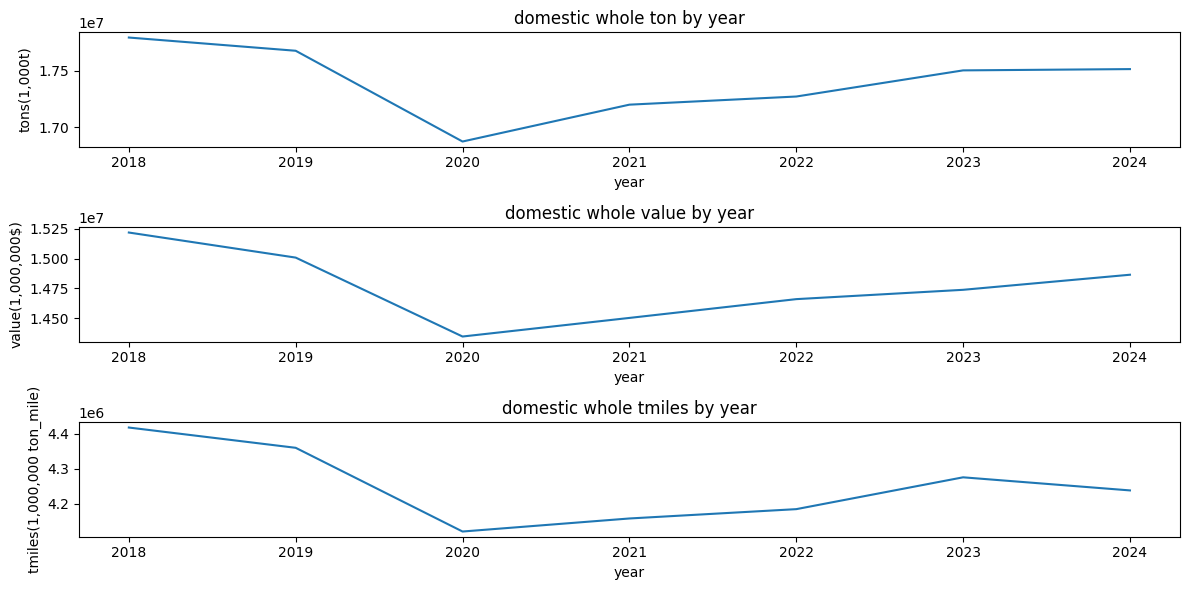

In [38]:
fig, axs = plt.subplots(3,1, figsize = (12,6))

sns.lineplot(x = [year for year in range(2018,2025)], y = dms_whole_tons, ax = axs[0])
axs[0].set_title('domestic whole ton by year')
axs[0].set_xlabel('year')
axs[0].set_ylabel('tons(1,000t)')

sns.lineplot(x = [year for year in range(2018,2025)], y = dms_whole_value, ax = axs[1])
axs[1].set_title('domestic whole value by year')
axs[1].set_xlabel('year')
axs[1].set_ylabel('value(1,000,000$)')

sns.lineplot(x = [year for year in range(2018,2025)], y = dms_whole_tmiles, ax = axs[2])
axs[2].set_title('domestic whole tmiles by year')
axs[2].set_xlabel('year')
axs[2].set_ylabel('tmiles(1,000,000 ton_mile)')

plt.tight_layout()
plt.show()

- 2020년도 1월 코로나 발발로 전체 물동량 감소 -> 23년도 부터는 다시 회복 추이

### 수입 총 톤/실질가치/tmiles

In [39]:
# 국내 운송 전체 요약
import_whole_tons = [fr_import[f'tons_{year}'].sum() for year in range(2018,2025)]
import_whole_value = [fr_import[f'value_{year}'].sum() for year in range(2018,2025)]
import_whole_tmiles = [fr_import[f'tmiles_{year}'].sum() for year in range(2018,2025)]

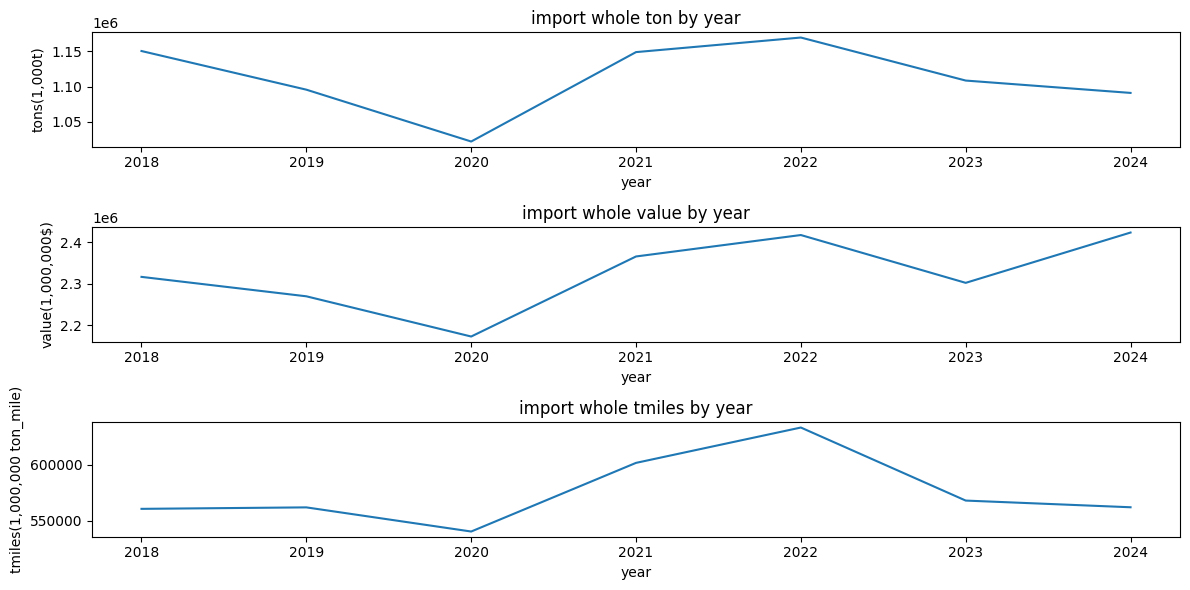

In [40]:
fig, axs = plt.subplots(3,1, figsize = (12,6))

sns.lineplot(x = [year for year in range(2018,2025)], y = import_whole_tons, ax = axs[0])
axs[0].set_title('import whole ton by year')
axs[0].set_xlabel('year')
axs[0].set_ylabel('tons(1,000t)')

sns.lineplot(x = [year for year in range(2018,2025)], y = import_whole_value, ax = axs[1])
axs[1].set_title('import whole value by year')
axs[1].set_xlabel('year')
axs[1].set_ylabel('value(1,000,000$)')

sns.lineplot(x = [year for year in range(2018,2025)], y = import_whole_tmiles, ax = axs[2])
axs[2].set_title('import whole tmiles by year')
axs[2].set_xlabel('year')
axs[2].set_ylabel('tmiles(1,000,000 ton_mile)')

plt.tight_layout()
plt.show()

- 코로나 기간 동안 수입량이 증가 

-> 코로나 기간에 미국 수입이 증가했다는 기사가 있긴 있다. 서비스에 대한 수요 감소와 물품에 대한 수요가 증가해서 그에 따른 물품 수입량이 증가...?

In [41]:
# 국내 운송 전체 요약
export_whole_tons = [fr_export[f'tons_{year}'].sum() for year in range(2018,2025)]
export_whole_value = [fr_export[f'value_{year}'].sum() for year in range(2018,2025)]
export_whole_tmiles = [fr_export[f'tmiles_{year}'].sum() for year in range(2018,2025)]

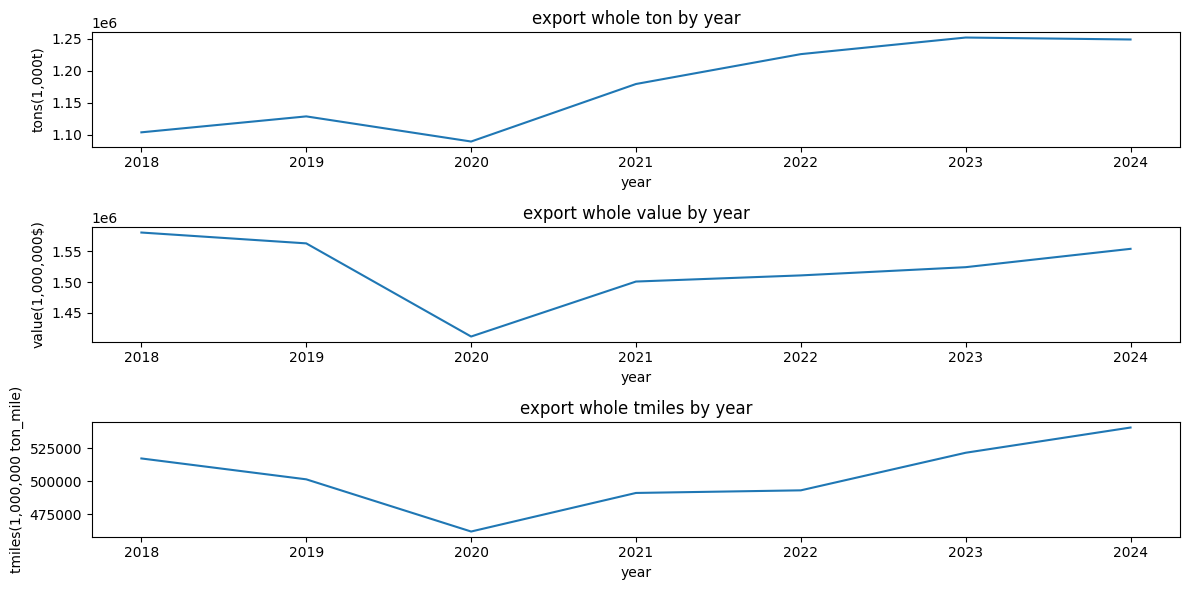

In [42]:
fig, axs = plt.subplots(3,1, figsize = (12,6))

sns.lineplot(x = [year for year in range(2018,2025)], y = export_whole_tons, ax = axs[0])
axs[0].set_title('export whole ton by year')
axs[0].set_xlabel('year')
axs[0].set_ylabel('tons(1,000t)')

sns.lineplot(x = [year for year in range(2018,2025)], y = export_whole_value, ax = axs[1])
axs[1].set_title('export whole value by year')
axs[1].set_xlabel('year')
axs[1].set_ylabel('value(1,000,000$)')

sns.lineplot(x = [year for year in range(2018,2025)], y = export_whole_tmiles, ax = axs[2])
axs[2].set_title('export whole tmiles by year')
axs[2].set_xlabel('year')
axs[2].set_ylabel('tmiles(1,000,000 ton_mile)')

plt.tight_layout()
plt.show()

- 전체 수출도 20년도에 하락세를 찍고, 21년도 부터 다시 수출량 증가

##### 미국 국내/수입/수출량 요약

2020년 코로나 기간에 물동량 급감. 이후 21-22년도에 특히 수입량이 코로나 이전 이상으로 증가

이후 23년도에는 수입량이 감소하고, 수출량은 지속적인 증가추세
(미국 국내에는 엔드 코로나 이후 다시 서비스에 대한 지출이 증가하고, 물품에 대한 지출이 감소?)
(수출은 경기 회복...? 일까요?)

###### 이후 분석은?

-> 수입/수출 파생 변수 생성해서 수출 대비 수입 그래프...? 그려서 어떻게 해보지

-> 24년도에 ton은 감소하지만 value가 증가한 것으로 보아, 무게가 적은 고부가가치 상품...? 을 수입한 것으로 추측. 관련 기사나 칼럼 찾아보기(사실 안 쓸지도 몰라요)

- 18년 부터 24년까지 명목 가치를 기준으로 주요 물품 비중을 pie chart로 시각화

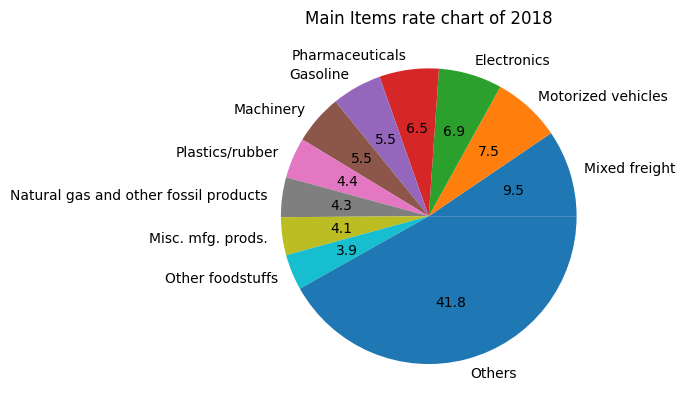

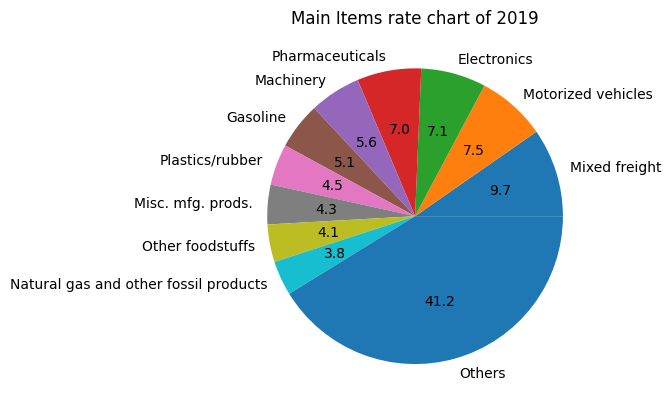

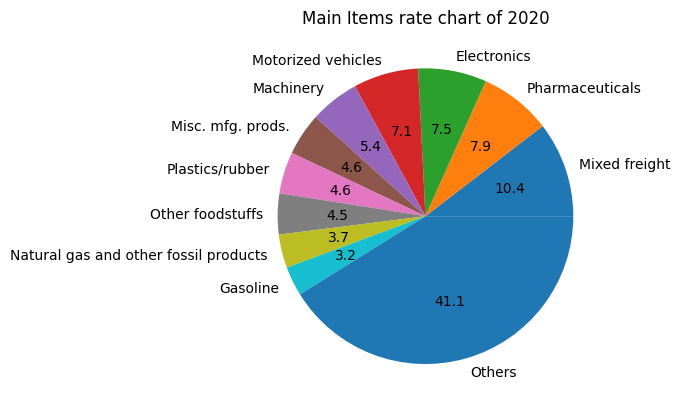

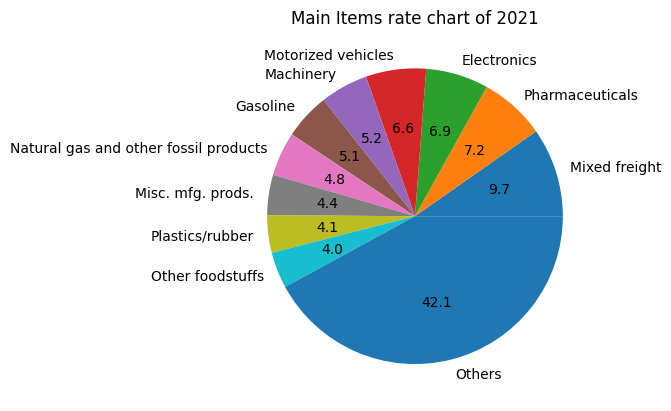

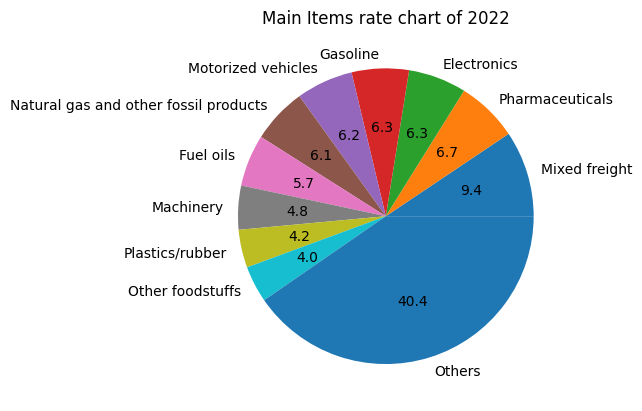

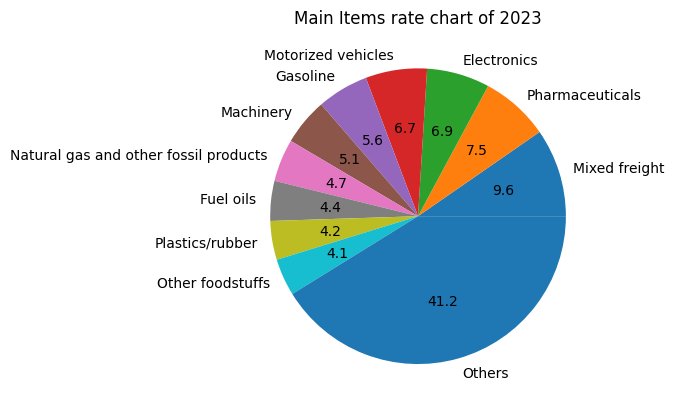

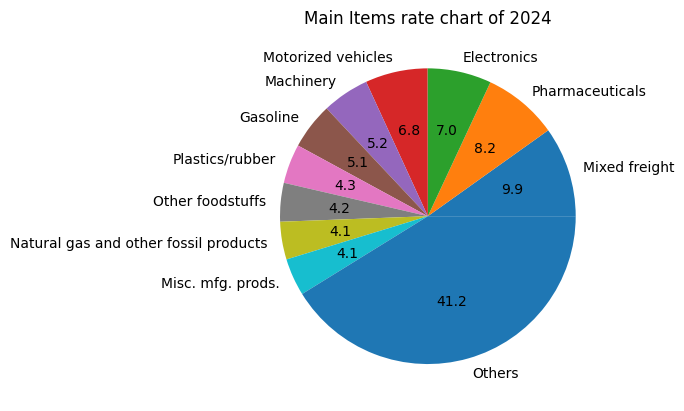

In [65]:
for year in range(2018,2025):
    c_value_by_sctg = dms_df.groupby(['sctg2_name'], observed = True)\
        [[f'current_value_{year}']].\
            sum().sort_values(by = f'current_value_{year}', ascending = False)
    
    top_10_names = c_value_by_sctg.index[:10].tolist()
    
    top_10 = c_value_by_sctg.head(10)
    others = c_value_by_sctg.iloc[10:][f'current_value_{year}'].sum()

    others_df = pd.DataFrame({f'current_value_{year}':[others]}, index=['Others'])

    pie_df = pd.concat([top_10, others_df])

    plt.pie(pie_df[f'current_value_{year}'], labels = pie_df.index, autopct = '%.1f')
    plt.title(f'Main Items rate chart of {year}')
    plt.show()

국내에서 18 ~ 24년도 까지의 주 물품은 Mixed freight, Motorized Vehicles, Electronics(전자제품), Pharmaceuticals(의약품)이다.

역시 코로나 19 이후 Pharmaceuticals의 전체 순위가 2등으로 올라온 것을 확인할 수 있다.

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


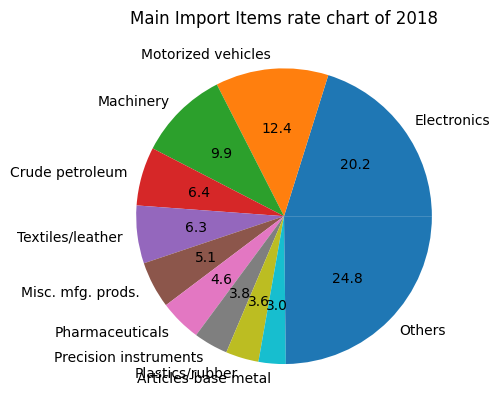

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


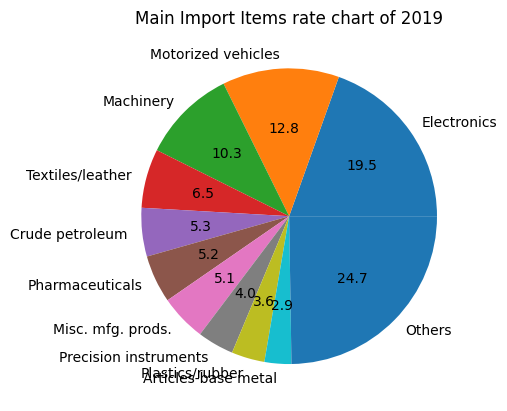

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


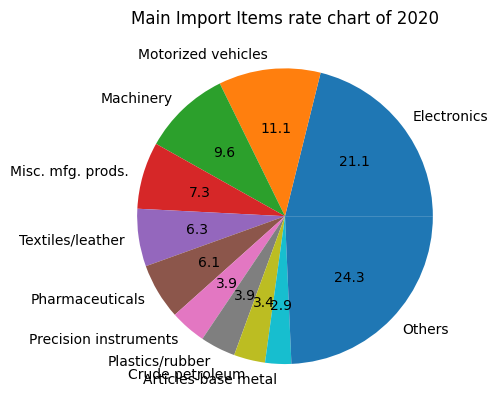

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


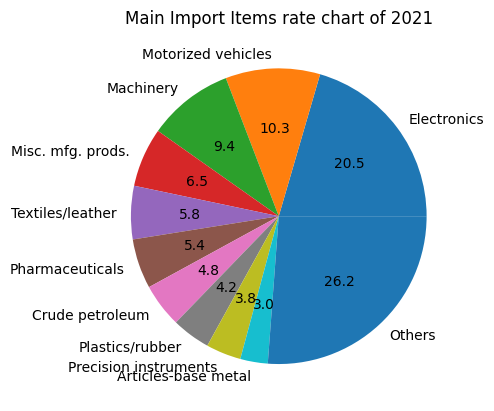

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


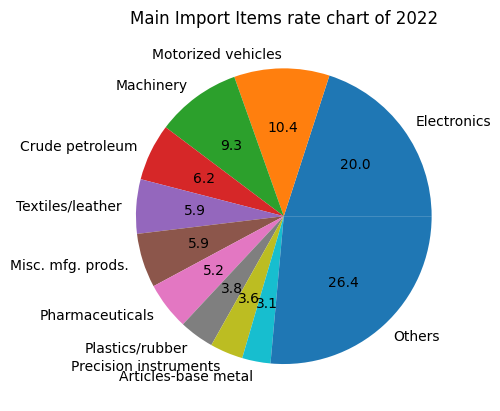

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


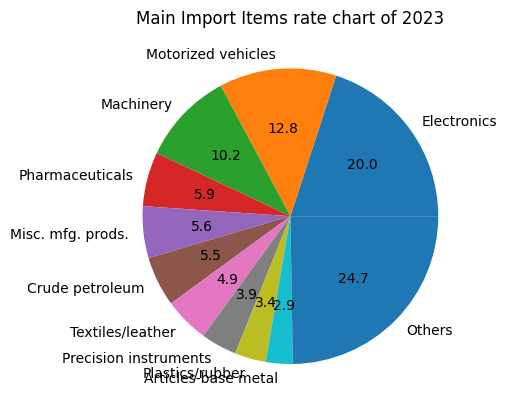

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


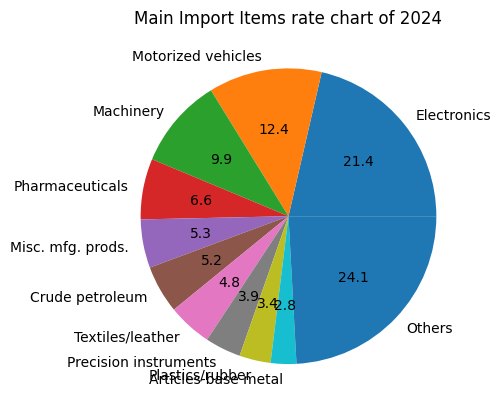

In [44]:
for year in range(2018,2025):
    c_value_by_sctg = fr_import.groupby(['sctg2_name'], observed = True)\
        [[f'current_value_{year}']].\
            sum().sort_values(by = f'current_value_{year}', ascending = False)
    
    top_10_names = c_value_by_sctg.index[:10].tolist()
    
    top_10 = c_value_by_sctg.head(10)
    others = c_value_by_sctg.iloc[10:].sum()

    others_df = pd.DataFrame({f'current_value_{year}':[others]}, index=['Others'])

    pie_df = pd.concat([top_10, others_df])

    plt.pie(pie_df[f'current_value_{year}'], labels = pie_df.index, autopct = '%.1f')
    plt.title(f'Main Import Items rate chart of {year}')
    plt.show()

금액으로 확인한 주요 수입품은 Electronics, Motorized Vechicles, Machiney로 7년간 순위 변동이 존재하지 않는다.

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


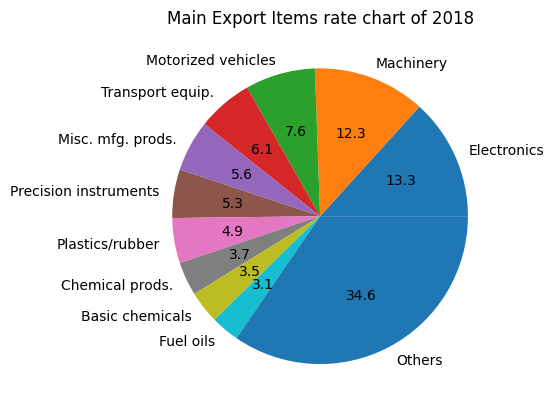

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


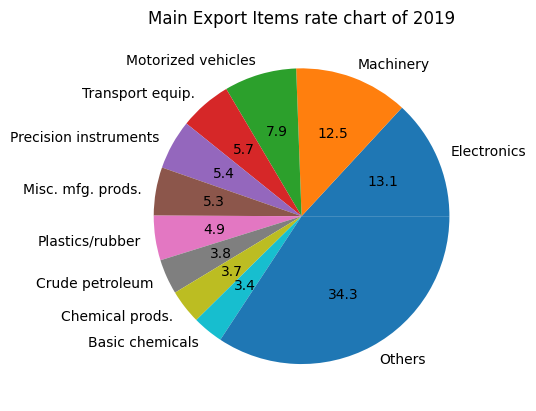

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


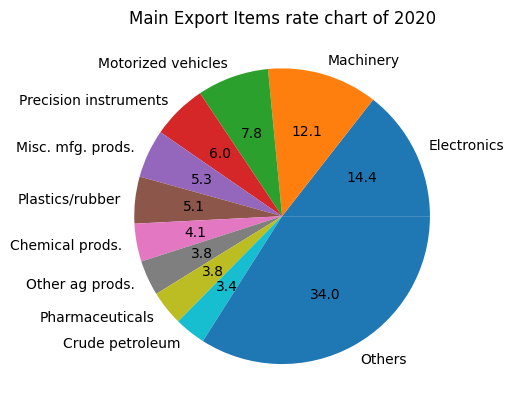

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


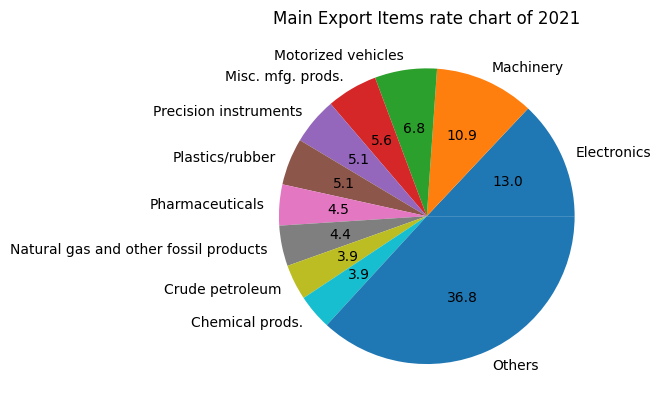

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


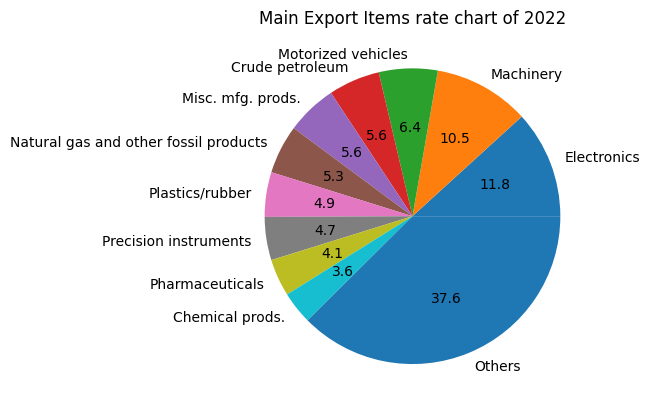

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


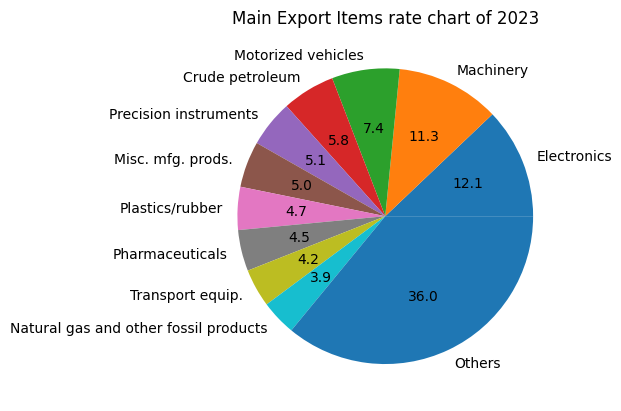

c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\matplotlib\axes\_axes.py:3358: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = np.asarray(x, np.float32)


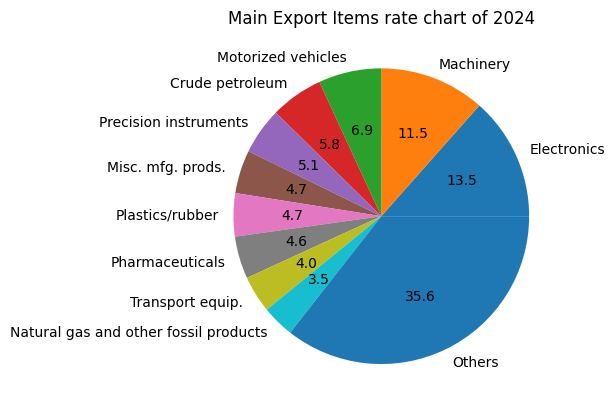

In [45]:
for year in range(2018,2025):
    c_value_by_sctg = fr_export.groupby(['sctg2_name'], observed = True)\
        [[f'current_value_{year}']].\
            sum().sort_values(by = f'current_value_{year}', ascending = False)
    
    top_10_names = c_value_by_sctg.index[:10].tolist()
    
    top_10 = c_value_by_sctg.head(10)
    others = c_value_by_sctg.iloc[10:].sum()

    others_df = pd.DataFrame({f'current_value_{year}':[others]}, index=['Others'])

    pie_df = pd.concat([top_10, others_df])

    plt.pie(pie_df[f'current_value_{year}'], labels = pie_df.index, autopct = '%.1f')
    plt.title(f'Main Export Items rate chart of {year}')
    plt.show()

주요 수출품 역시 Electronics, Machinery, Moterized vechicles 세 가지이다.

2024년 Top 10 품목 연도별 실질가치 트렌드

- 앞선 파이 차트가 큰 의미가 없어보여서, lineplot으로 추세를 확인

In [46]:
value_by_sctg2 = dms_df.groupby(['sctg2_name'], observed = True)[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

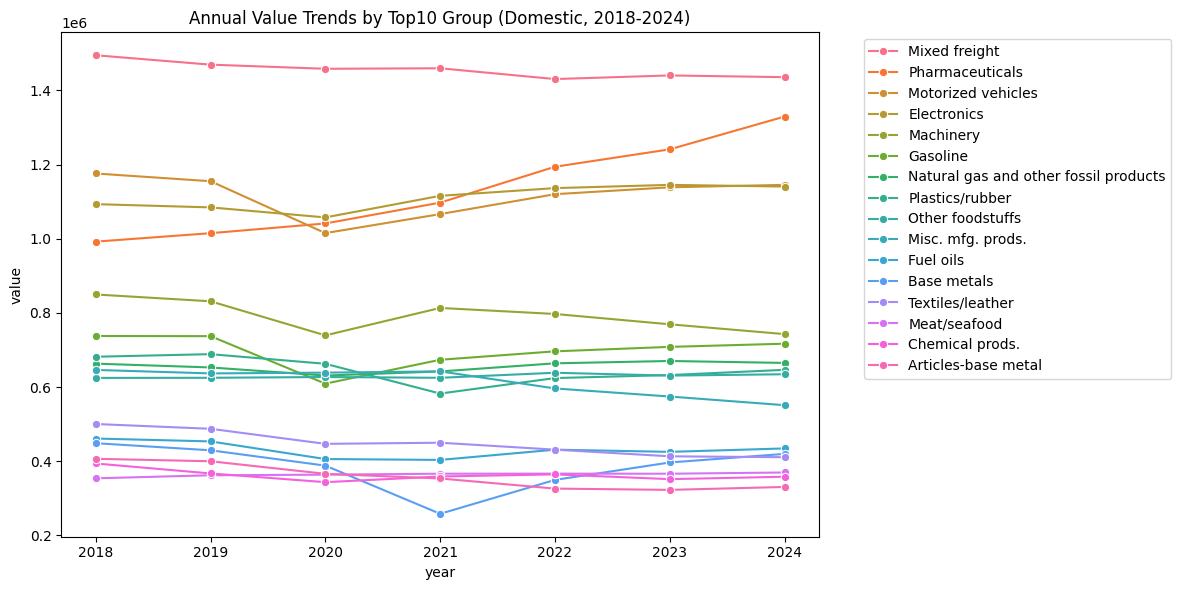

In [47]:
value_by_sctg2_melted = value_by_sctg2.melt(id_vars = 'sctg2_name',
                                            var_name = 'year',
                                            value_name = 'value').reset_index(drop = True)

value_by_sctg2_melted['year'] = value_by_sctg2_melted['year'].str.replace('value_','').astype(int)

sort_order = value_by_sctg2_melted[value_by_sctg2_melted['year'] == 2024].sort_values(
    'value', ascending = False).reset_index(drop = True)

top_10 = sort_order.loc[:15,'sctg2_name']
df_top_10 = value_by_sctg2_melted[value_by_sctg2_melted['sctg2_name'].isin(top_10)]

plt.figure(figsize = (12,6))
sns.lineplot(data = df_top_10, x = 'year', y = 'value', hue = 'sctg2_name', marker = 'o',
            hue_order= top_10)
plt.title('Annual Value Trends by Top10 Group (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

눈에 띄는 특징은 국내 물품 중 의약품의 금액이 지속적으로 증가하는 것을 확인할 수 있다.

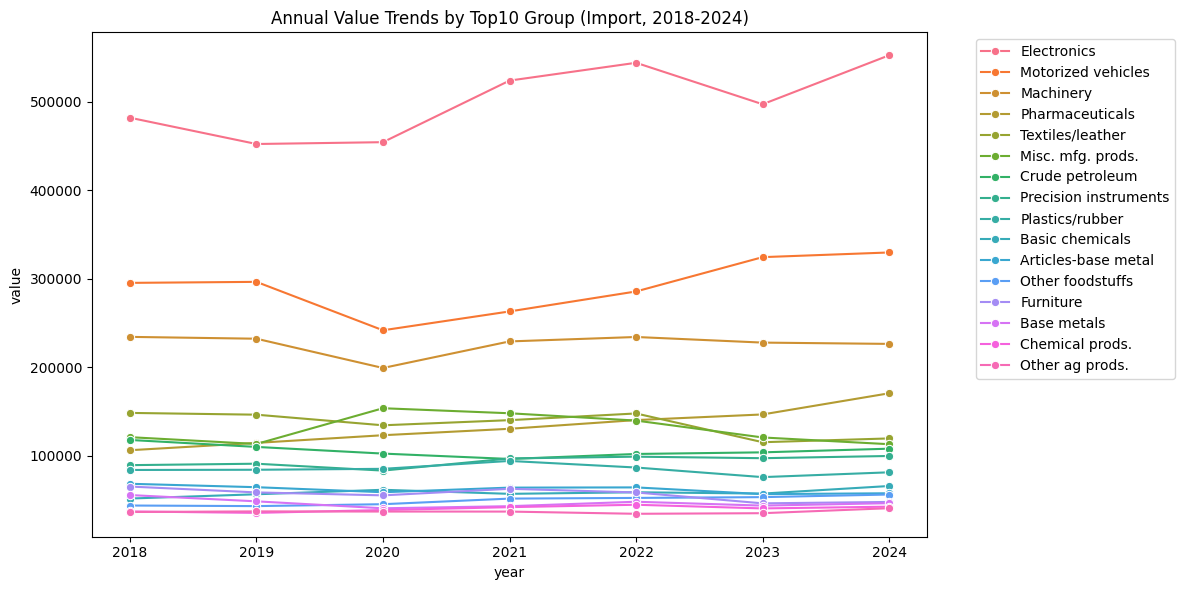

In [48]:
value_by_sctg2 = fr_import.groupby(['sctg2_name'], observed = True)\
    [[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

value_by_sctg2_melted = value_by_sctg2.melt(id_vars = 'sctg2_name',
                                            var_name = 'year',
                                            value_name = 'value').reset_index(drop = True)

value_by_sctg2_melted['year'] = value_by_sctg2_melted['year'].str.replace('value_','').astype(int)

sort_order = value_by_sctg2_melted[value_by_sctg2_melted['year'] == 2024].sort_values(
    'value', ascending = False).reset_index(drop = True)

top_10 = sort_order.loc[:15,'sctg2_name']
df_top_10 = value_by_sctg2_melted[value_by_sctg2_melted['sctg2_name'].isin(top_10)]

plt.figure(figsize = (12,6))
sns.lineplot(data = df_top_10, x = 'year', y = 'value', hue = 'sctg2_name', marker = 'o',
            hue_order= top_10)
plt.title('Annual Value Trends by Top10 Group (Import, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

수입품 역시 파이 차트와 동일하게 3가지 품목이 주를 이룬다.

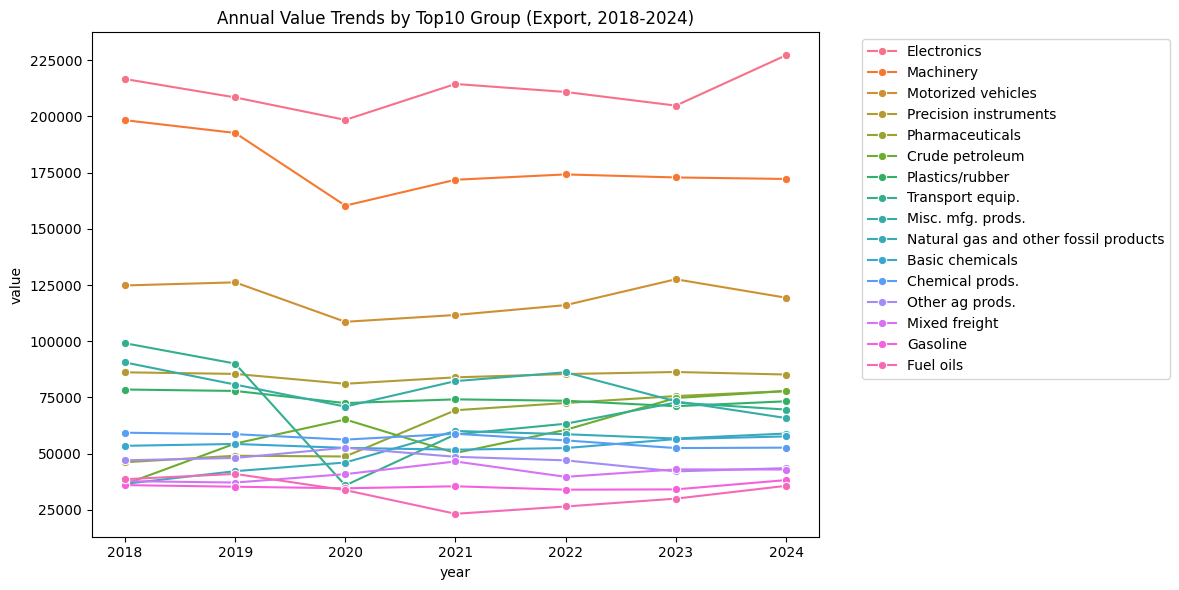

In [49]:
value_by_sctg2 = fr_export.groupby(['sctg2_name'], observed = True)\
    [[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

value_by_sctg2_melted = value_by_sctg2.melt(id_vars = 'sctg2_name',
                                            var_name = 'year',
                                            value_name = 'value').reset_index(drop = True)

value_by_sctg2_melted['year'] = value_by_sctg2_melted['year'].str.replace('value_','').astype(int)

sort_order = value_by_sctg2_melted[value_by_sctg2_melted['year'] == 2024].sort_values(
    'value', ascending = False).reset_index(drop = True)

top_10 = sort_order.loc[:15,'sctg2_name']
df_top_10 = value_by_sctg2_melted[value_by_sctg2_melted['sctg2_name'].isin(top_10)]

plt.figure(figsize = (12,6))
sns.lineplot(data = df_top_10, x = 'year', y = 'value', hue = 'sctg2_name', marker = 'o',
            hue_order= top_10)
plt.title('Annual Value Trends by Top10 Group (Export, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

In [50]:
df_top_10[df_top_10['sctg2_name'] == 'Transport equip.']

,sctg2_name,year,value
39,Transport equip.,2018,99120.957638
81,Transport equip.,2019,90075.873951
123,Transport equip.,2020,35909.767567
165,Transport equip.,2021,58582.464407
207,Transport equip.,2022,63325.767320
249,Transport equip.,2023,72737.355057
291,Transport equip.,2024,69620.806676


수출품 역시 상위 3개 품목이 동일하게 보인다.

특이사항은 Transport equip이 코로나 시작 연도(2020)에 급감하는 것을 알 수 있다.

-> 이에 대한 이유는 찾지 못 했다. 데이터가 참 어렵네

2024년 Top 10 품목 연도별 톤 트렌드

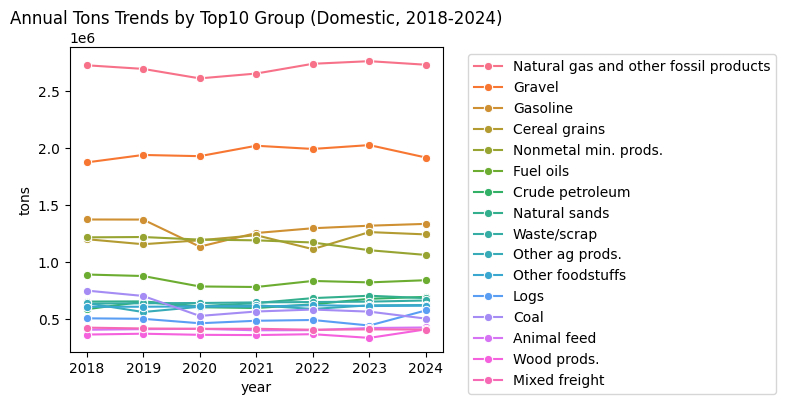

In [16]:
value_by_sctg2 = dms_df.groupby(['sctg2_name'], observed = True)\
    [[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

value_by_sctg2_melted = value_by_sctg2.melt(id_vars = 'sctg2_name',
                                            var_name = 'year',
                                            value_name = 'tons').reset_index(drop = True)

value_by_sctg2_melted['year'] = value_by_sctg2_melted['year'].str.replace('tons_','').astype(int)

sort_order = value_by_sctg2_melted[value_by_sctg2_melted['year'] == 2024].sort_values(
    'tons', ascending = False).reset_index(drop = True)

top_10 = sort_order.loc[:15,'sctg2_name']
df_top_10 = value_by_sctg2_melted[value_by_sctg2_melted['sctg2_name'].isin(top_10)]

plt.figure(figsize = (8,4))
sns.lineplot(data = df_top_10, x = 'year', y = 'tons', hue = 'sctg2_name', marker = 'o',
            hue_order= top_10)
plt.title('Annual Tons Trends by Top10 Group (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

톤을 기준으로 보았을 때 국내 물품 중 Natural Gas and other fossil products가 가장 많고,

Gravel(자갈, 돌), Gasolin, Cereal grains, Nonmetal min. prods. 순.

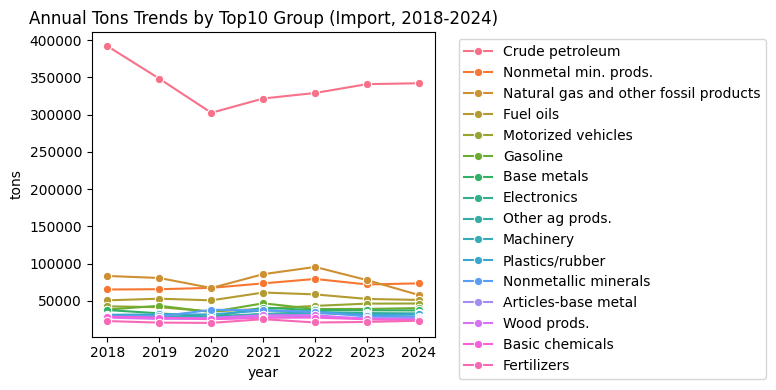

In [15]:
value_by_sctg2 = fr_import.groupby(['sctg2_name'], observed = True)\
    [[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

value_by_sctg2_melted = value_by_sctg2.melt(id_vars = 'sctg2_name',
                                            var_name = 'year',
                                            value_name = 'tons').reset_index(drop = True)

value_by_sctg2_melted['year'] = value_by_sctg2_melted['year'].str.replace('tons_','').astype(int)

sort_order = value_by_sctg2_melted[value_by_sctg2_melted['year'] == 2024].sort_values(
    'tons', ascending = False).reset_index(drop = True)

top_10 = sort_order.loc[:15,'sctg2_name']
df_top_10 = value_by_sctg2_melted[value_by_sctg2_melted['sctg2_name'].isin(top_10)]

plt.figure(figsize = (8,4))
sns.lineplot(data = df_top_10, x = 'year', y = 'tons', hue = 'sctg2_name', marker = 'o',
            hue_order= top_10)
plt.title('Annual Tons Trends by Top10 Group (Import, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

수입품은 Crudo petroleum(원유, 석유) / Nonmetal / Natural Gas

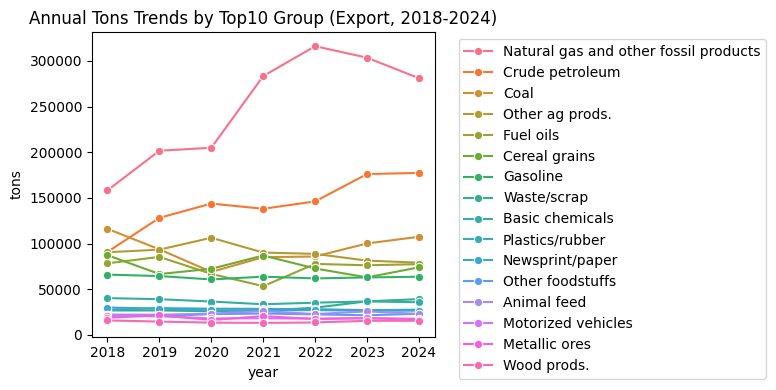

In [14]:
value_by_sctg2 = fr_export.groupby(['sctg2_name'], observed = True)\
    [[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

value_by_sctg2_melted = value_by_sctg2.melt(id_vars = 'sctg2_name',
                                            var_name = 'year',
                                            value_name = 'tons').reset_index(drop = True)

value_by_sctg2_melted['year'] = value_by_sctg2_melted['year'].str.replace('tons_','').astype(int)

sort_order = value_by_sctg2_melted[value_by_sctg2_melted['year'] == 2024].sort_values(
    'tons', ascending = False).reset_index(drop = True)

top_10 = sort_order.loc[:15,'sctg2_name']
df_top_10 = value_by_sctg2_melted[value_by_sctg2_melted['sctg2_name'].isin(top_10)]

plt.figure(figsize = (8,4))
sns.lineplot(data = df_top_10, x = 'year', y = 'tons', hue = 'sctg2_name', marker = 'o',
            hue_order= top_10)
plt.title('Annual Tons Trends by Top10 Group (Export, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

수출품은 Natural Gas, Crude petroleum, Coal ... 등?

출발지-도착지 기준 groupby

In [ ]:
od_grouped = dms_df.groupby(['state_orig','state_dest'], observed = True)\
    [[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

od_grouped.sort_values(by = 'tons_2024', ascending = False).head(20)

,dms_orig,dms_dest,tons_2018,tons_2019,tons_2020,tons_2021,tons_2022,tons_2023,tons_2024
15120,486,486,395311.767374,388791.770651,358470.177657,362200.367798,386584.467242,400574.078095,405747.362778
15493,489,489,345003.551046,360705.841594,334939.525272,342961.720388,335782.669870,349786.466904,347240.386842
1064,61,61,356365.991598,352291.944082,333044.252311,342923.255639,339577.223502,326335.700739,329574.469721
5296,190,190,327741.330553,332585.810049,316176.328757,336697.084652,320685.656310,324417.454466,321812.959427
14855,484,484,297151.232178,302823.766975,279374.841534,287435.529466,301988.345294,309964.391208,313464.467785
17222,559,559,235873.284316,228783.246038,224460.475596,227974.385629,239252.145617,229920.188322,231345.360380
4631,179,179,225151.776138,208834.369949,212824.024383,216896.014944,215309.912404,220483.199405,220966.775285
4365,171,171,201373.269884,199998.161853,189772.363889,191279.460355,193606.769441,192129.689110,193963.067230
9009,319,319,170031.066330,170257.434346,168437.002246,172547.714033,147099.540268,163337.284636,176642.305357
3447,129,129,160353.077441,163962.301058,160664.359970,159101.072177,175378.965603,165787.435946,174341.038238


상위 20개까지 출발지와 최종 도착지가 같은 곳을 확인

대안책은 크게 2가지로 생각.

1. 출발지로만 groupby, 도착지로만 groupby해서 주요 생산지와 도착지를 확인한다.

2. 출발지와 도착지가 다른 곳만 filtering 후, OD로 다시 groupby를 진행해 인사이트를 찾아본다.

출발지로 groupby

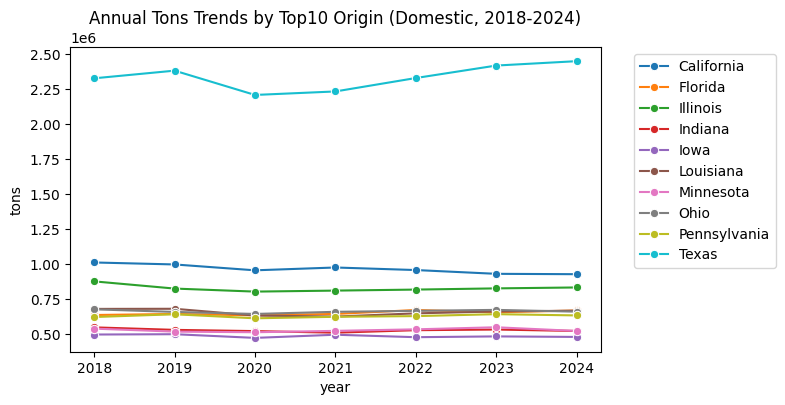

In [9]:
dms_orig_tons = dms_df.groupby(['state_orig_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

dms_orig_tons_10 = dms_orig_tons.sort_values(by = 'tons_2024', ascending = False).head(10)

if dms_orig_tons_10['state_orig_nm'].dtype.name == 'category':
    dms_orig_tons_10['state_orig_nm'] = dms_orig_tons_10['state_orig_nm'].cat.remove_unused_categories()

orig_tons_10_melt = dms_orig_tons_10.melt(id_vars = 'state_orig_nm',
                    var_name = 'year',
                    value_name = 'tons').reset_index(drop = True)

orig_tons_10_melt['year'] = orig_tons_10_melt['year'].str.replace('tons_','')

plt.figure(figsize = (8,4))
sns.lineplot(data = orig_tons_10_melt, x = 'year', y = 'tons', hue = 'state_orig_nm', marker = 'o')
plt.title('Annual Tons Trends by Top10 Origin (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

주로 어디에서 출발했는지(Tons 기준)

Rest of TX가 압도적, 그 이후 Houston TX, Iowa

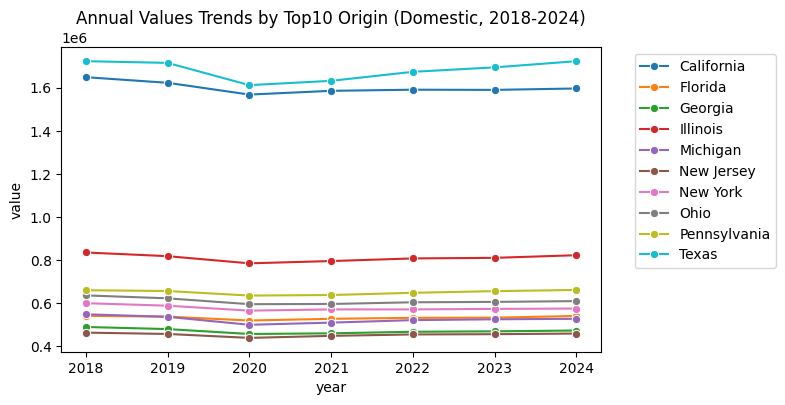

In [10]:
dms_orig_values = dms_df.groupby(['state_orig_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

dms_orig_tons_10 = dms_orig_values.sort_values(by = 'value_2024', ascending = False).head(10)

if dms_orig_tons_10['state_orig_nm'].dtype.name == 'category':
    dms_orig_tons_10['state_orig_nm'] = dms_orig_tons_10['state_orig_nm'].cat.remove_unused_categories()

orig_tons_10_melt = dms_orig_tons_10.melt(id_vars = 'state_orig_nm',
                    var_name = 'year',
                    value_name = 'value').reset_index(drop = True)

orig_tons_10_melt['year'] = orig_tons_10_melt['year'].str.replace('value_','')

plt.figure(figsize = (8,4))
sns.lineplot(data = orig_tons_10_melt, x = 'year', y = 'value', hue = 'state_orig_nm', marker = 'o')
plt.title('Annual Values Trends by Top10 Origin (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

명목 가치 기준

Los Angeles CA, Chicaco, Houston, Dallas-Fort

도착지로 groupby

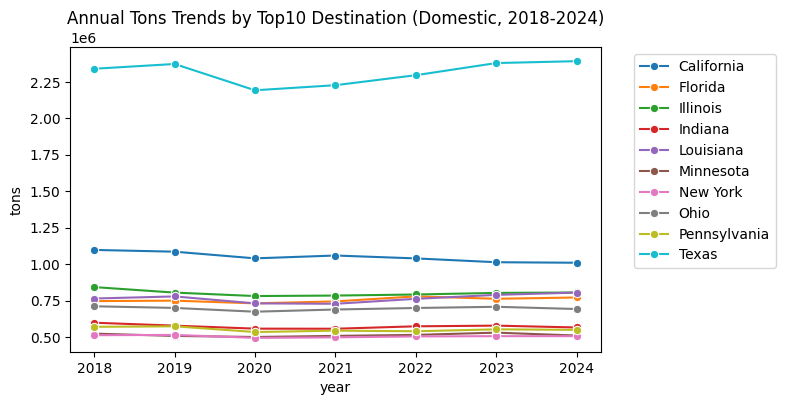

In [11]:
dms_dest_tons = dms_df.groupby(['state_dest_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

dms_dest_tons_10 = dms_dest_tons.sort_values(by = 'tons_2024', ascending = False).head(10)

if dms_dest_tons_10['state_dest_nm'].dtype.name == 'category':
    dms_dest_tons_10['state_dest_nm'] = dms_dest_tons_10['state_dest_nm'].cat.remove_unused_categories()

dest_tons_10_melt = dms_dest_tons_10.melt(id_vars = 'state_dest_nm',
                    var_name = 'year',
                    value_name = 'tons').reset_index(drop = True)

dest_tons_10_melt['year'] = dest_tons_10_melt['year'].str.replace('tons_','')

plt.figure(figsize = (8,4))
sns.lineplot(data = dest_tons_10_melt, x = 'year', y = 'tons', hue = 'state_dest_nm', marker = 'o')
plt.title('Annual Tons Trends by Top10 Destination (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

도착지 기준 톤

Houston TX, Rest of TX, Los Angeles CA, Iowa

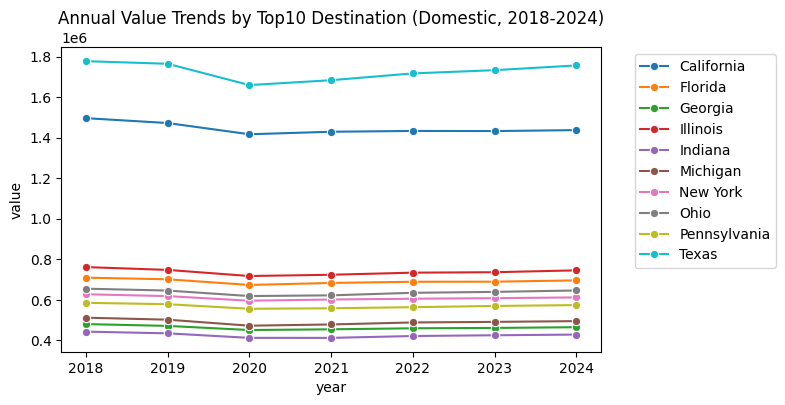

In [12]:
dms_dest_tons = dms_df.groupby(['state_dest_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

dms_dest_tons_10 = dms_dest_tons.sort_values(by = 'value_2024', ascending = False).head(10)

if dms_dest_tons_10['state_dest_nm'].dtype.name == 'category':
    dms_dest_tons_10['state_dest_nm'] = dms_dest_tons_10['state_dest_nm'].cat.remove_unused_categories()

dest_tons_10_melt = dms_dest_tons_10.melt(id_vars = 'state_dest_nm',
                    var_name = 'year',
                    value_name = 'value').reset_index(drop = True)

dest_tons_10_melt['year'] = dest_tons_10_melt['year'].str.replace('value_','')

plt.figure(figsize = (8,4))
sns.lineplot(data = dest_tons_10_melt, x = 'year', y = 'value', hue = 'state_dest_nm', marker = 'o')
plt.title('Annual Value Trends by Top10 Destination (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

In [102]:
dms_df['dms_orig_nm'].nunique()

132

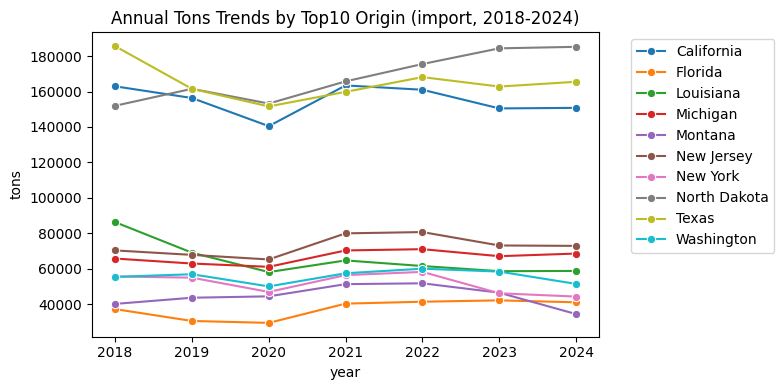

In [ ]:
dms_orig_tons = fr_import.groupby(['state_orig_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

dms_orig_tons_10 = dms_orig_tons.sort_values(by = 'tons_2024', ascending = False).head(10)

if dms_orig_tons_10['state_orig_nm'].dtype.name == 'category':
    dms_orig_tons_10['state_orig_nm'] = dms_orig_tons_10['state_orig_nm'].cat.remove_unused_categories()

orig_tons_10_melt = dms_orig_tons_10.melt(id_vars = 'state_orig_nm',
                    var_name = 'year',
                    value_name = 'tons').reset_index(drop = True)

orig_tons_10_melt['year'] = orig_tons_10_melt['year'].str.replace('tons_','')

plt.figure(figsize = (8,4))
sns.lineplot(data = orig_tons_10_melt, x = 'year', y = 'tons', hue = 'state_orig_nm', marker = 'o')
plt.title('Annual Tons Trends by Top10 Origin (import, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

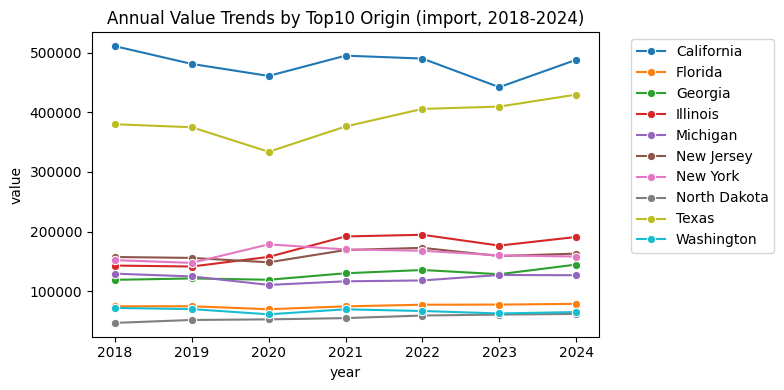

In [99]:
dms_orig_tons = fr_import.groupby(['state_orig_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

dms_orig_tons_10 = dms_orig_tons.sort_values(by = 'value_2024', ascending = False).head(10)

if dms_orig_tons_10['state_orig_nm'].dtype.name == 'category':
    dms_orig_tons_10['state_orig_nm'] = dms_orig_tons_10['state_orig_nm'].cat.remove_unused_categories()

orig_tons_10_melt = dms_orig_tons_10.melt(id_vars = 'state_orig_nm',
                    var_name = 'year',
                    value_name = 'value').reset_index(drop = True)

orig_tons_10_melt['year'] = orig_tons_10_melt['year'].str.replace('value_','')

plt.figure(figsize = (8,4))
sns.lineplot(data = orig_tons_10_melt, x = 'year', y = 'value', hue = 'state_orig_nm', marker = 'o')
plt.title('Annual Value Trends by Top10 Origin (import, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

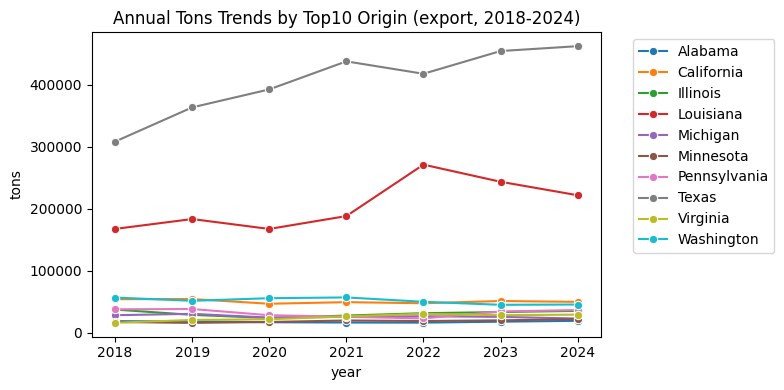

In [101]:
dms_orig_tons = fr_export.groupby(['state_orig_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

dms_orig_tons_10 = dms_orig_tons.sort_values(by = 'tons_2024', ascending = False).head(10)

if dms_orig_tons_10['state_orig_nm'].dtype.name == 'category':
    dms_orig_tons_10['state_orig_nm'] = dms_orig_tons_10['state_orig_nm'].cat.remove_unused_categories()

orig_tons_10_melt = dms_orig_tons_10.melt(id_vars = 'state_orig_nm',
                    var_name = 'year',
                    value_name = 'tons').reset_index(drop = True)

orig_tons_10_melt['year'] = orig_tons_10_melt['year'].str.replace('tons_','')

plt.figure(figsize = (8,4))
sns.lineplot(data = orig_tons_10_melt, x = 'year', y = 'tons', hue = 'state_orig_nm', marker = 'o')
plt.title('Annual Tons Trends by Top10 Origin (export, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

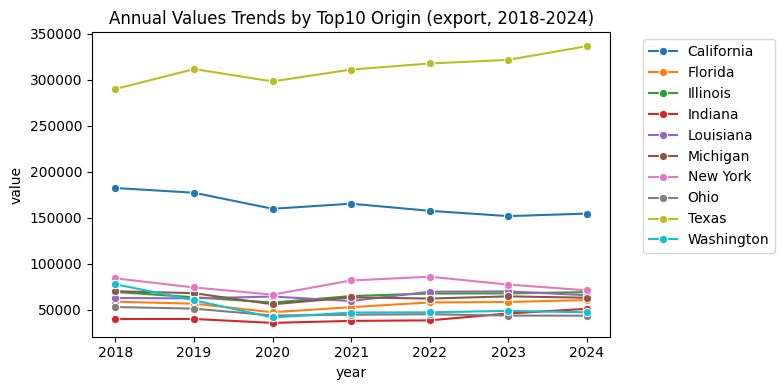

In [102]:
dms_orig_tons = fr_export.groupby(['state_orig_nm'], observed = True)\
[[f'value_{year}' for year in range(2018,2025)]].sum().reset_index()

dms_orig_tons_10 = dms_orig_tons.sort_values(by = 'value_2024', ascending = False).head(10)

if dms_orig_tons_10['state_orig_nm'].dtype.name == 'category':
    dms_orig_tons_10['state_orig_nm'] = dms_orig_tons_10['state_orig_nm'].cat.remove_unused_categories()

orig_tons_10_melt = dms_orig_tons_10.melt(id_vars = 'state_orig_nm',
                    var_name = 'year',
                    value_name = 'value').reset_index(drop = True)

orig_tons_10_melt['year'] = orig_tons_10_melt['year'].str.replace('value_','')

plt.figure(figsize = (8,4))
sns.lineplot(data = orig_tons_10_melt, x = 'year', y = 'value', hue = 'state_orig_nm', marker = 'o')
plt.title('Annual Values Trends by Top10 Origin (export, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

도착지 기준 금액(Value)

Los Angeles CA, Houston TX, Chicago, Dallas

ton은 낮은데 Value가 높은 곳 -> Los Angeles CA

여기는 반도체 같은 고부가가치 상품을 파는 곳인가?

둘다 높은 곳 -> Houston TX, Chicaco, Dallas

여기가 미국의 메인 허브일 가능성이 높음 -> 여기는 주로 뭘 팔지?


-> 일단 주요 허브일 가능성이 높은 곳은 Los Angeles CA, Houston TX, Chicago, Dallas

1. 주요 허브들에 대해서 주요 품목을 내볼까?

2. 로스엔젤레스 같이 생산량에 비해 가치가 높은 곳은 좀 더 비싼 걸 파는 곳이지 않을까? -> value / tons으로 파생 변수 만들어서 sort 해볼까?

3. 그럼 반대로, ton / value로 돈에 비해서 많은 걸 생산하는 건 어떤 의미를 가지지? 이것도 잘은 모르겠지만 일단 해볼까?

In [83]:
orig_c_value = dms_df.groupby(['dms_orig_nm'], observed = True)['current_value_2024'].sum().sort_values().reset_index()

orig_tons = dms_df.groupby(['dms_orig_nm'], observed = True)['tons_2024'].sum().sort_values().reset_index()

orig_value_tons = pd.merge(orig_c_value, orig_tons, on = 'dms_orig_nm')

orig_value_tons.head()

,dms_orig_nm,current_value_2024,tons_2024
0,Washington DC-VA-MD-WV (DC Part),4714.686882,5962.797880
1,Rest of HI,9564.392838,12554.924677
2,Rest of NH,10878.799083,11189.553293
3,Rest of DE,14552.872232,12811.209951
4,Laredo TX,18328.677342,31385.716663


In [ ]:
orig_value_tons['c_value_divided_tons'] = orig_value_tons['current_value_2024'] / orig_value_tons['tons_2024']

orig_value_tons.sort_values(by = 'c_value_divided_tons' , ascending = False)

,dms_orig_nm,current_value_2024,tons_2024,c_value_divided_tons
64,New York NY-NJ-CT-PA (PA Part),1.048660e+05,32708.739967,3.206054
84,Greensboro--Winston-Salem--High Point NC,1.401451e+05,46556.482322,3.010216
80,Memphis TN-MS-AR (TN Part),1.337674e+05,46259.572474,2.891669
63,Hartford CT,1.043941e+05,36616.623606,2.851004
131,Los Angeles CA,1.159327e+06,431679.336055,2.685622
...,...,...,...,...
23,Montana,4.665154e+04,101982.058941,0.457449
45,South Dakota,7.141644e+04,158039.496917,0.451890
81,North Dakota,1.348858e+05,334057.982345,0.403780
54,West Virginia,9.032632e+04,231164.303285,0.390745


<Axes: xlabel='current_value_2024', ylabel='tons_2024'>

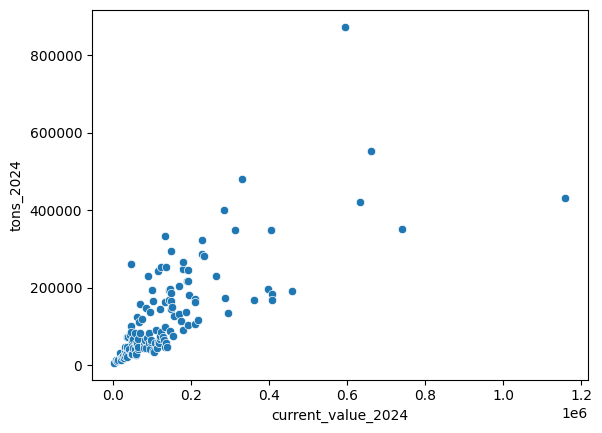

In [85]:
sns.scatterplot(orig_value_tons, x = 'current_value_2024', y = 'tons_2024')

In [18]:
df.columns

Index(['fr_orig', 'dms_orig', 'dms_dest', 'fr_dest', 'fr_inmode', 'dms_mode',
       'fr_outmode', 'sctg2', 'trade_type', 'dist_band', 'tons_2018',
       'tons_2019', 'tons_2020', 'tons_2021', 'tons_2022', 'tons_2023',
       'tons_2024', 'value_2018', 'value_2019', 'value_2020', 'value_2021',
       'value_2022', 'value_2023', 'value_2024', 'current_value_2018',
       'current_value_2019', 'current_value_2020', 'current_value_2021',
       'current_value_2022', 'current_value_2023', 'current_value_2024',
       'tmiles_2018', 'tmiles_2019', 'tmiles_2020', 'tmiles_2021',
       'tmiles_2022', 'tmiles_2023', 'tmiles_2024', 'dms_mode_nm',
       'fr_inmode_nm', 'fr_outmode_nm', 'trade_type_nm', 'dist_band_nm',
       'sctg2_name', 'dms_orig_nm', 'dms_dest_nm', 'state_orig', 'state_dest',
       'state_orig_nm', 'state_dest_nm', 'fr_orig_nm', 'fr_dest_nm'],
      dtype='object')

In [ ]:
# 명목가치 기준
tmp_df = df.groupby(['sctg2_name'])['current_value_2024'].sum().reset_index().sort_values(by = 'current_value_2024', ascending = False)

tmp_df['current_rate_2024'] = tmp_df['current_value_2024'] / sum(tmp_df['current_value_2024'])
tmp_df

C:\Users\user\AppData\Local\Temp\ipykernel_1972\3494802096.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp_df = df.groupby(['sctg2_name'])['current_value_2024'].sum().reset_index().sort_values(by = 'current_value_2024', ascending = False)


,sctg2_name,current_value_2024,current_rate_2024
10,Electronics,2.311174e+06,0.093295
23,Mixed freight,2.026495e+06,0.081803
33,Pharmaceuticals,1.906295e+06,0.076951
24,Motorized vehicles,1.862905e+06,0.075199
18,Machinery,1.554872e+06,0.062765
14,Gasoline,1.068686e+06,0.043139
22,Misc. mfg. prods.,1.064546e+06,0.042972
34,Plastics/rubber,1.047072e+06,0.042267
31,Other foodstuffs,9.424095e+05,0.038042
25,Natural gas and other fossil products,9.030999e+05,0.036455


In [39]:
# 톤 기준
tmp_df = df.groupby(['sctg2_name'])['tons_2024'].sum().reset_index().sort_values(by = 'tons_2024', ascending = False)

tmp_df['tons_rate_2024'] = tmp_df['tons_2024'] / sum(tmp_df['tons_2024'])
tmp_df

C:\Users\user\AppData\Local\Temp\ipykernel_1972\3543612740.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp_df = df.groupby(['sctg2_name'])['tons_2024'].sum().reset_index().sort_values(by = 'tons_2024', ascending = False)


,sctg2_name,tons_2024,tons_rate_2024
25,Natural gas and other fossil products,3.073602e+06,0.154799
15,Gravel,1.926674e+06,0.097035
14,Gasoline,1.441285e+06,0.072589
6,Cereal grains,1.323454e+06,0.066655
9,Crude petroleum,1.215516e+06,0.061218
28,Nonmetal min. prods.,1.150990e+06,0.057969
12,Fuel oils,9.712152e+05,0.048914
30,Other ag prods.,7.359155e+05,0.037064
40,Waste/scrap,7.134649e+05,0.035933
26,Natural sands,6.936440e+05,0.034935


In [25]:
df.columns

Index(['fr_orig', 'dms_orig', 'dms_dest', 'fr_dest', 'fr_inmode', 'dms_mode',
       'fr_outmode', 'sctg2', 'trade_type', 'dist_band', 'tons_2018',
       'tons_2019', 'tons_2020', 'tons_2021', 'tons_2022', 'tons_2023',
       'tons_2024', 'value_2018', 'value_2019', 'value_2020', 'value_2021',
       'value_2022', 'value_2023', 'value_2024', 'current_value_2018',
       'current_value_2019', 'current_value_2020', 'current_value_2021',
       'current_value_2022', 'current_value_2023', 'current_value_2024',
       'tmiles_2018', 'tmiles_2019', 'tmiles_2020', 'tmiles_2021',
       'tmiles_2022', 'tmiles_2023', 'tmiles_2024', 'dms_mode_nm',
       'fr_inmode_nm', 'fr_outmode_nm', 'trade_type_nm', 'dist_band_nm',
       'sctg2_name', 'dms_orig_nm', 'dms_dest_nm', 'state_orig', 'state_dest',
       'state_orig_nm', 'state_dest_nm', 'fr_orig_nm', 'fr_dest_nm'],
      dtype='object')

In [34]:
tmp_df = df[df['sctg2'].isin([i for i in range(1,10)])].groupby('sctg2')['dms_mode'].value_counts().reset_index()

tmp_df[tmp_df['sctg2'] == 1]

,sctg2,dms_mode,count
0,1,1,7533
1,1,4,5365
2,1,5,2821
3,1,7,693
4,1,2,76
5,1,3,9


In [38]:
tmp_df[tmp_df['sctg2'] == 4]

,sctg2,dms_mode,count
18,4,1,16941
19,4,4,10073
20,4,2,9665
21,4,5,6909
22,4,3,1002
23,4,7,35


### 1차 이상치 처리?

In [48]:
def scatter_plot(y, x_limit=None, y_limit=None):
    tons_col = f'tons_{y}'
    value_col = f'value_{y}'

    plt.figure(figsize=(12, 8))

    # 산점도 그리기 (각 그룹별로 색상과 라벨 지정)
    plt.scatter(dms_df[tons_col], dms_df[value_col], color='blue', alpha=0.4, label='Domestic (1)', s=10)
    plt.scatter(fr_import[tons_col], fr_import[value_col], color='green', alpha=0.4, label='Import (2)', s=10)
    plt.scatter(fr_export[tons_col], fr_export[value_col], color='red', alpha=0.4, label='Export (3)', s=10)

    # 축 범위 설정
    if x_limit:
        plt.xlim(0, x_limit)
    if y_limit:
        plt.ylim(0, y_limit)

    # 그래프 꾸미기
    plt.title(f'Tons vs Value by Trade Type ({y})', fontsize=15)
    plt.xlabel('Tons (Kilotons)', fontsize=12)
    plt.ylabel('Value (Million $)', fontsize=12)
    plt.legend() # 범례 표시
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [49]:
# 국내 산점도
def scatter_plot_dms(y, x_limit=None, y_limit=None):
    tons_col = f'tons_{y}'
    value_col = f'value_{y}'

    plt.figure(figsize=(12, 8))

    plt.scatter(dms_df[tons_col], dms_df[value_col], s=10)

    if x_limit:
        plt.xlim(0, x_limit)
    if y_limit:
        plt.ylim(0, y_limit)

    # 그래프 꾸미기
    plt.title(f'[Domestic] Tons vs Value by Trade Type ({y})', fontsize=15)
    plt.xlabel('Tons (Kilotons)', fontsize=12)
    plt.ylabel('Value (Million $)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# 수입 산점도
def scatter_plot_im(y, x_limit=None, y_limit=None):
    tons_col = f'tons_{y}'
    value_col = f'value_{y}'

    plt.figure(figsize=(12, 8))

    plt.scatter(fr_import[tons_col], fr_import[value_col], s=10)

    if x_limit:
        plt.xlim(0, x_limit)
    if y_limit:
        plt.ylim(0, y_limit)

    # 그래프 꾸미기
    plt.title(f'[Import] Tons vs Value by Trade Type ({y})', fontsize=15)
    plt.xlabel('Tons (Kilotons)', fontsize=12)
    plt.ylabel('Value (Million $)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# 수출 산점도
def scatter_plot_ex(y, x_limit=None, y_limit=None):
    tons_col = f'tons_{y}'
    value_col = f'value_{y}'

    plt.figure(figsize=(12, 8))

    plt.scatter(fr_export[tons_col], fr_export[value_col], s=10)

    if x_limit:
        plt.xlim(0, x_limit)
    if y_limit:
        plt.ylim(0, y_limit)

    # 그래프 꾸미기
    plt.title(f'[Export] Tons vs Value by Trade Type ({y})', fontsize=15)
    plt.xlabel('Tons (Kilotons)', fontsize=12)
    plt.ylabel('Value (Million $)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

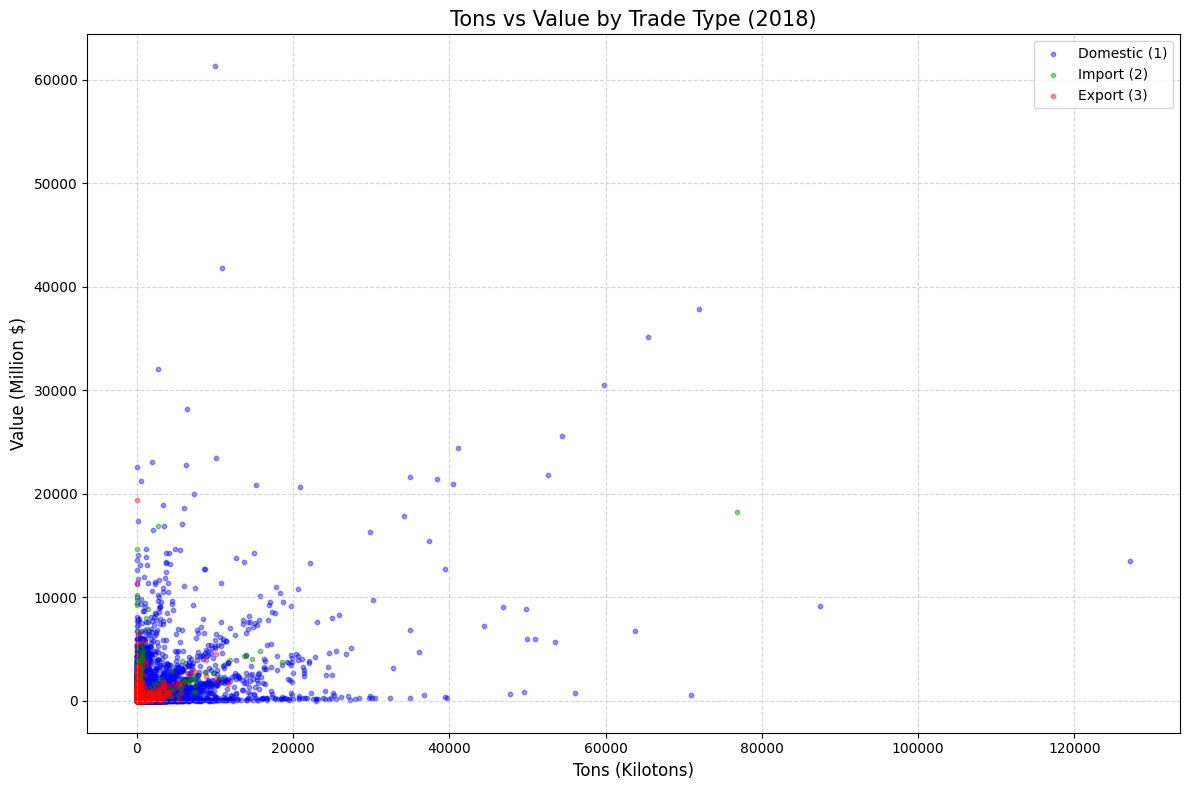

C:\Users\user\AppData\Local\Temp\ipykernel_1972\115077329.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\user\data_analysis\camp\project_eda_9\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


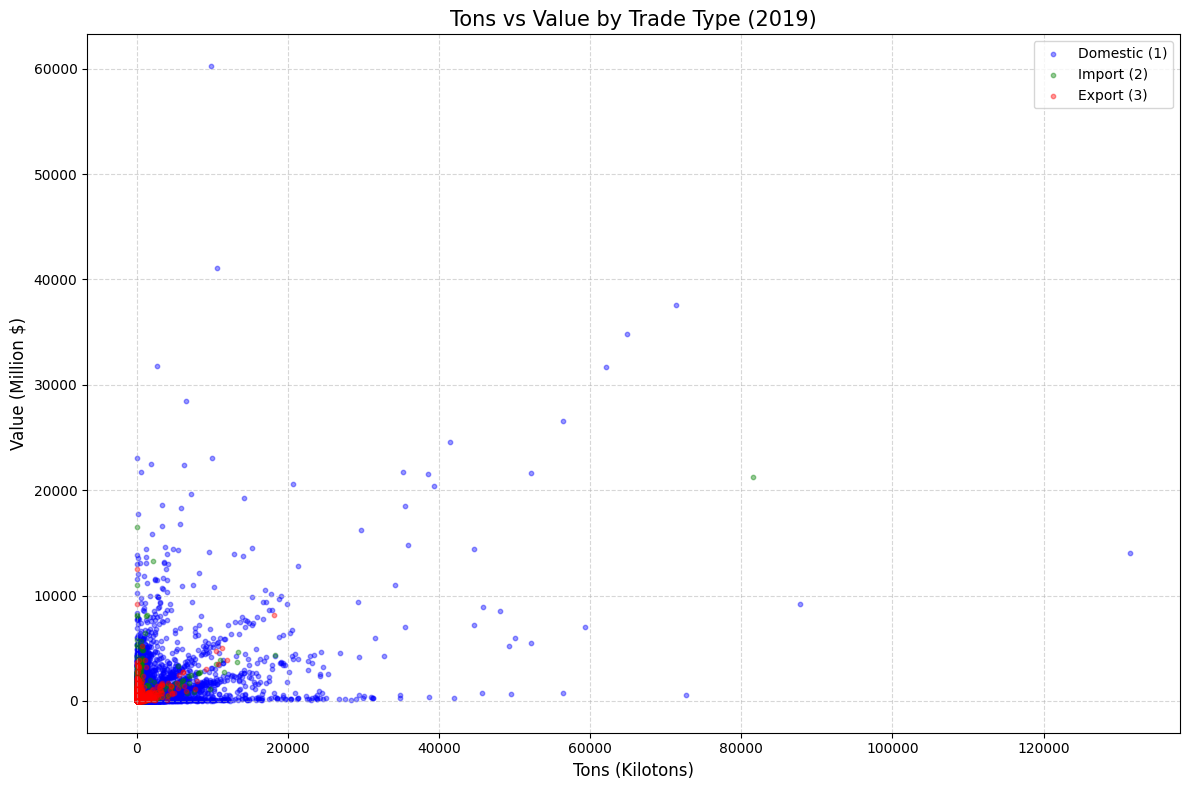

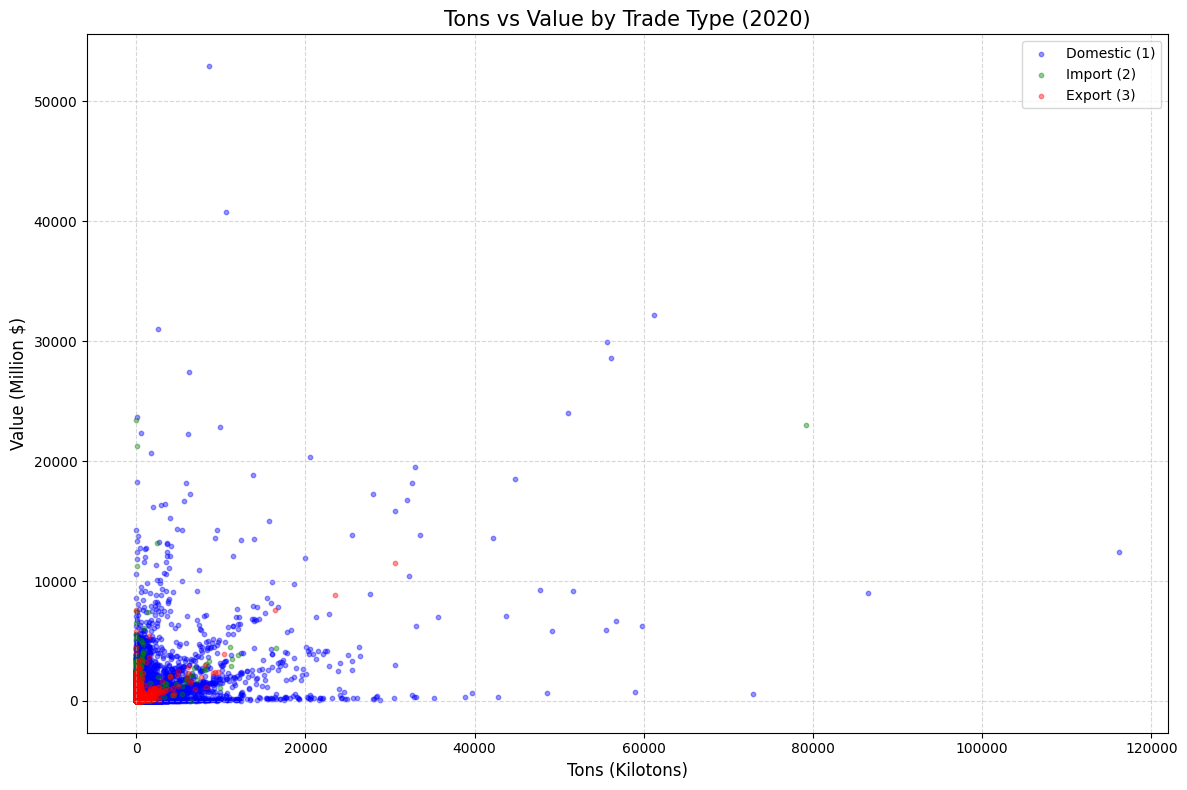

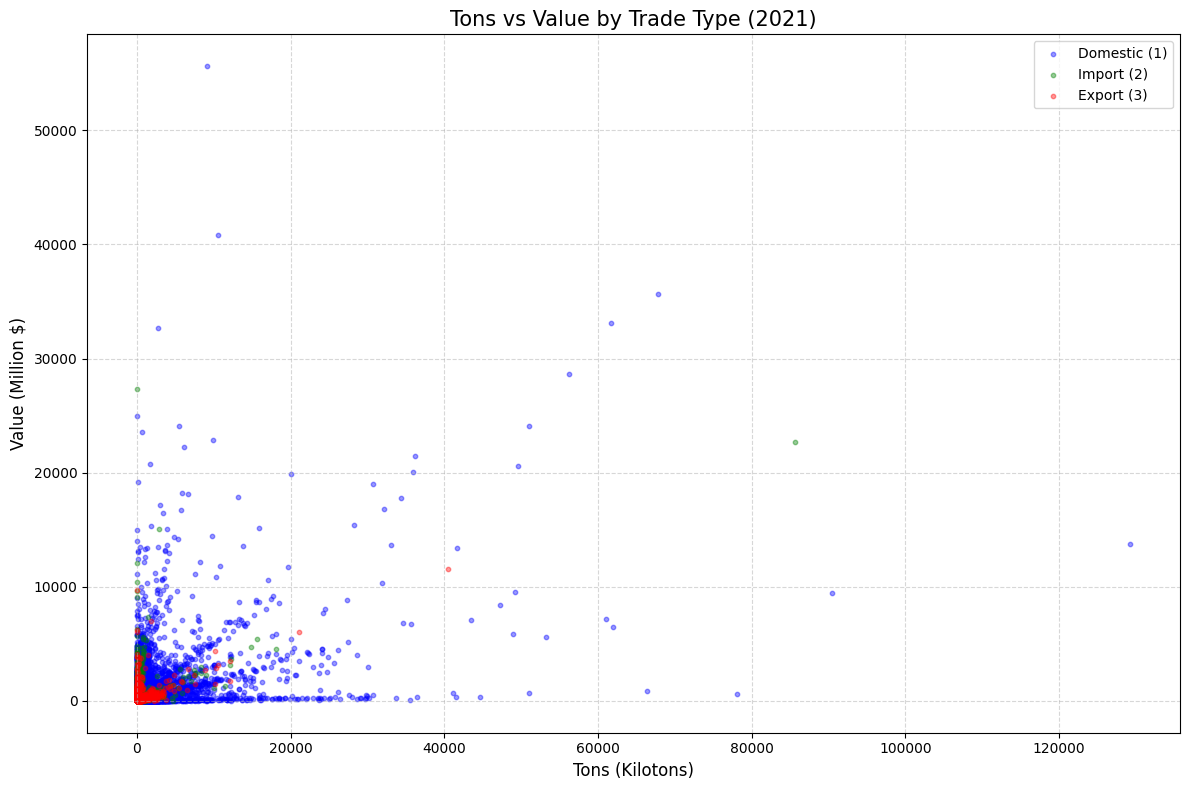

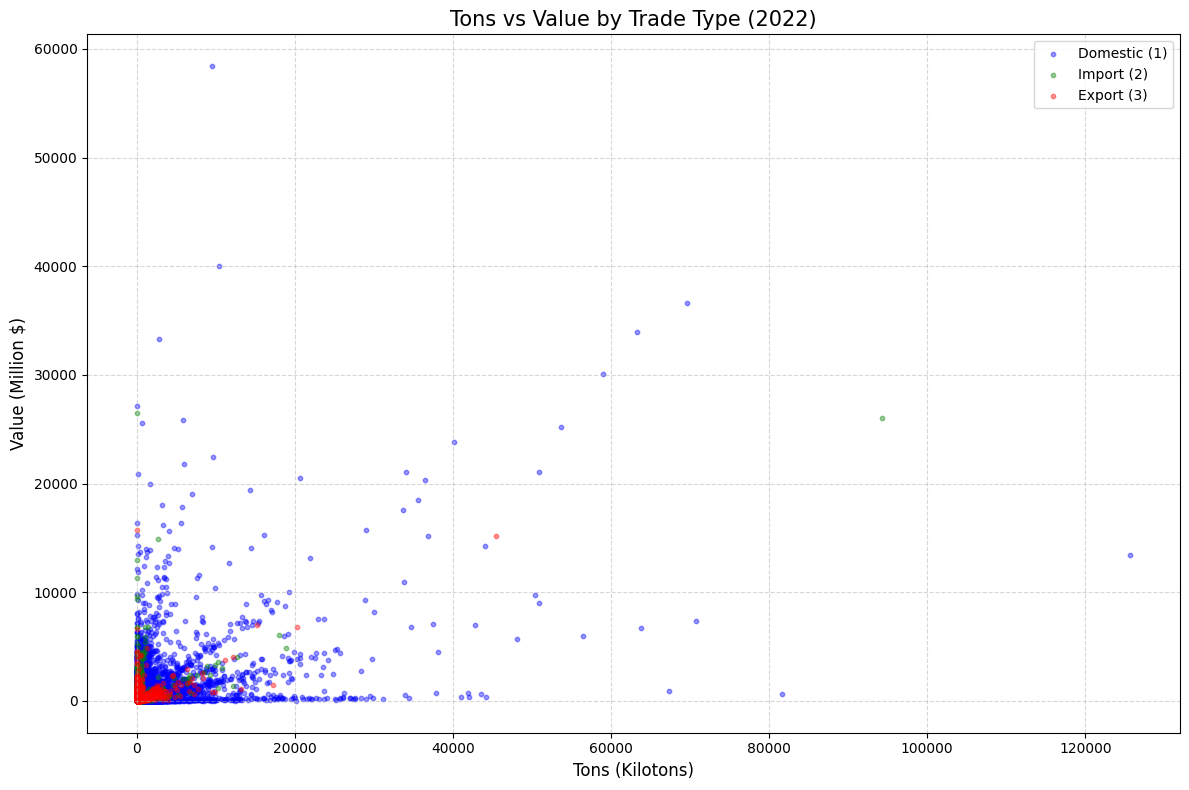

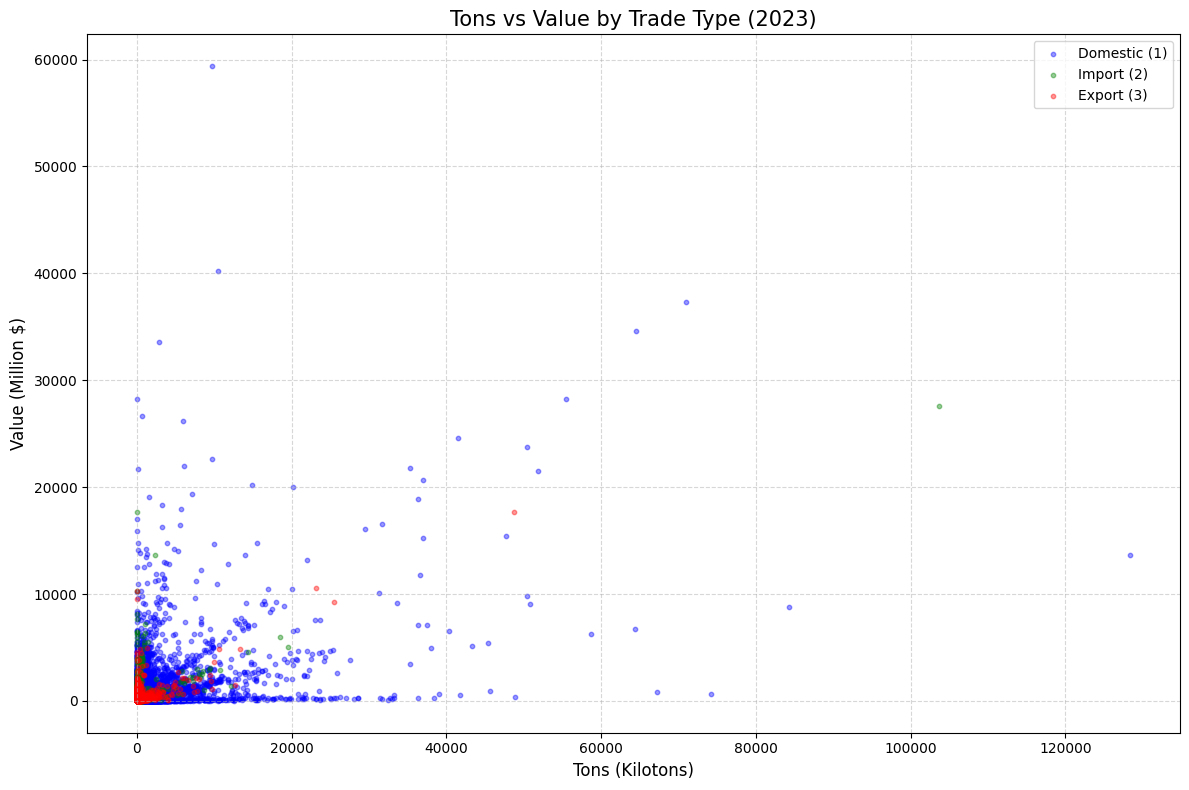

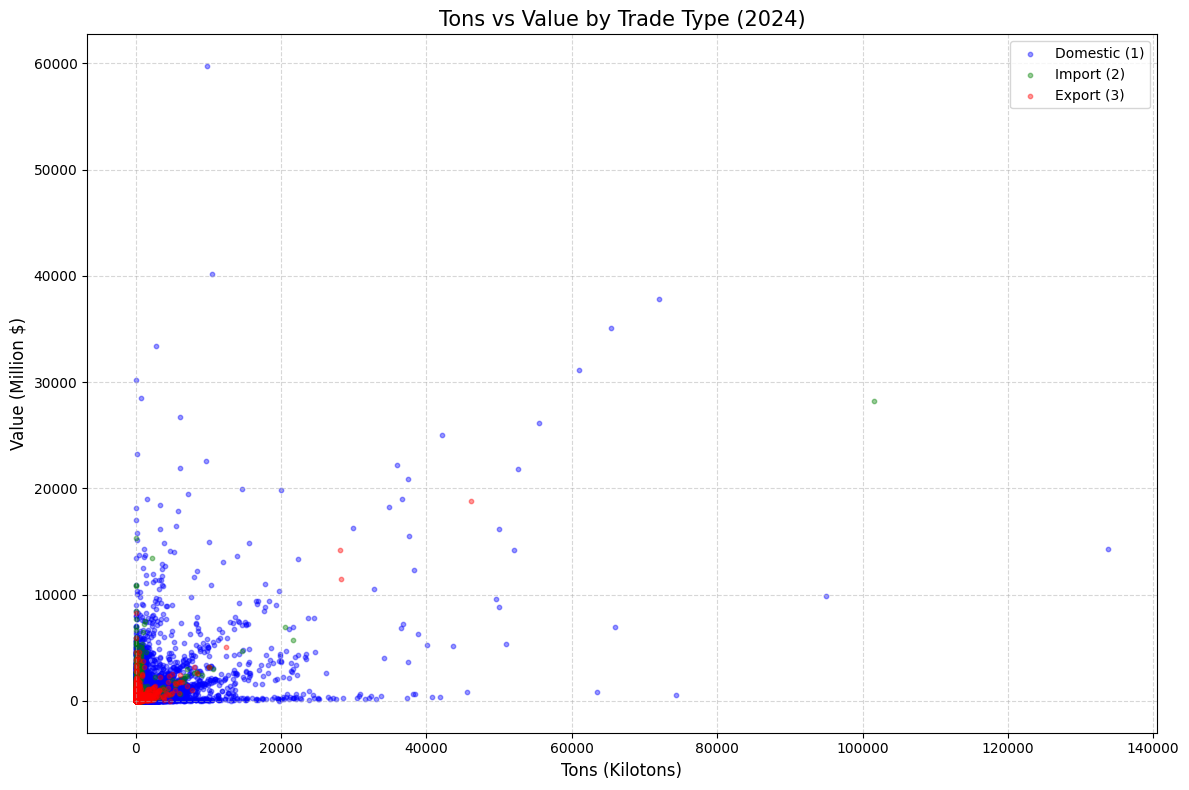

In [50]:
for year in range(2018, 2025):
    scatter_plot(year)

In [ ]:
# Crude Petroluem
b = fr_import[fr_import['tons_2018'] >= 60000]

,fr_orig,dms_orig,dms_dest,fr_inmode,dms_mode,sctg2,trade_type,dist_band,tons_2018,tons_2019,...,trade_type_nm,dist_band_nm,sctg2_name,dms_orig_nm,dms_dest_nm,state_orig,state_dest,state_orig_nm,state_dest_nm,fr_orig_nm
692711,801.0,380,171,6.0,6,16,2,5,76773.105503,81513.384174,...,Import flows (freight shipments moved from for...,750 - 999,Crude petroleum,North Dakota,Chicago IL-IN-WI (IL Part),38,17,North Dakota,Illinois,Canada


In [ ]:
c = fr_export[fr_export['tons_2023'] >= 20000]

,dms_orig,dms_dest,fr_dest,dms_mode,fr_outmode,sctg2,trade_type,dist_band,tons_2018,tons_2019,...,trade_type_nm,dist_band_nm,sctg2_name,dms_orig_nm,dms_dest_nm,state_orig,state_dest,state_orig_nm,state_dest_nm,fr_dest_nm
1700530,489,483,804.0,6,3.0,16,3,3,5963.499647,11963.932686,...,Export flows (freight shipments moved from US ...,250 - 499,Crude petroleum,Rest of TX,Corpus Christi TX,48,48,Texas,Texas,Europe
1700531,489,486,804.0,6,3.0,16,3,3,8853.346606,18172.006508,...,Export flows (freight shipments moved from US ...,250 - 499,Crude petroleum,Rest of TX,Houston TX,48,48,Texas,Texas,Europe
1700639,489,483,807.0,6,3.0,16,3,3,5190.022904,10753.610951,...,Export flows (freight shipments moved from US ...,250 - 499,Crude petroleum,Rest of TX,Corpus Christi TX,48,48,Texas,Texas,Eastern Asia


In [ ]:
# value_2024가 50000이상
# 주 : 미시간 -> 미시간 / 품목 :  자동차
dms_df[dms_df['value_2024'] >= 50000]

,dms_orig,dms_dest,dms_mode,sctg2,trade_type,dist_band,tons_2018,tons_2019,tons_2020,tons_2021,...,dms_mode_nm,trade_type_nm,dist_band_nm,sctg2_name,dms_orig_nm,dms_dest_nm,state_orig,state_dest,state_orig_nm,state_dest_nm
372833,261,261,1,36,1,1,10000.060205,9823.160302,8633.281478,9069.135658,...,Truck,Domestic flows (freight shipments moved from U...,Below 100,Motorized vehicles,Detroit MI,Detroit MI,26,26,Michigan,Michigan


### Top-OD를 그리기 위해, 동부로 물류 흐름이 이동했는데 주로 어떤 물류가 이동을 했을까?

##### 미국 서부 -> 동부로 물류 중심이 이동했다는 근거 자료조사 
###### 1. 항만 정체는 주로 컨테이너 선에 집중되었다. (해외 수입/수출 부분에서 water의 비중을 잘 봐야 할 듯.)
###### 2. tons 기준으로 아주 큰 놈들 보다는, 컨테이너로 옮길 수 있는 것들(의약품, 소비재, 가공식품)로 해석해야 올바른 해석이 될 것.

In [90]:
dms_df.columns

Index(['dms_orig', 'dms_dest', 'dms_mode', 'sctg2', 'trade_type', 'dist_band',
       'tons_2018', 'tons_2019', 'tons_2020', 'tons_2021', 'tons_2022',
       'tons_2023', 'tons_2024', 'value_2018', 'value_2019', 'value_2020',
       'value_2021', 'value_2022', 'value_2023', 'value_2024',
       'current_value_2018', 'current_value_2019', 'current_value_2020',
       'current_value_2021', 'current_value_2022', 'current_value_2023',
       'current_value_2024', 'tmiles_2018', 'tmiles_2019', 'tmiles_2020',
       'tmiles_2021', 'tmiles_2022', 'tmiles_2023', 'tmiles_2024',
       'dms_mode_nm', 'trade_type_nm', 'dist_band_nm', 'sctg2_name',
       'dms_orig_nm', 'dms_dest_nm', 'state_orig', 'state_dest',
       'state_orig_nm', 'state_dest_nm'],
      dtype='object')

In [ ]:
dms_df_2 = dms_df.groupby(['state_orig_nm'])

In [ ]:
dms_orig_tons = dms_df.groupby(['state_orig_nm'], observed = True)\
[[f'tons_{year}' for year in range(2018,2025)]].sum().reset_index()

dms_orig_tons_10 = dms_orig_tons.sort_values(by = 'tons_2024', ascending = False).head(10)

if dms_orig_tons_10['state_orig_nm'].dtype.name == 'category':
    dms_orig_tons_10['state_orig_nm'] = dms_orig_tons_10['state_orig_nm'].cat.remove_unused_categories()

orig_tons_10_melt = dms_orig_tons_10.melt(id_vars = 'state_orig_nm',
                    var_name = 'year',
                    value_name = 'tons').reset_index(drop = True)

orig_tons_10_melt['year'] = orig_tons_10_melt['year'].str.replace('tons_','')

plt.figure(figsize = (8,4))
sns.lineplot(data = orig_tons_10_melt, x = 'year', y = 'tons', hue = 'state_orig_nm', marker = 'o')
plt.title('Annual Tons Trends by Top10 Origin (Domestic, 2018-2024)')
plt.legend(bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.tight_layout()
plt.show()

,value_2018,value_2019,value_2020,value_2021,value_2022,value_2023,value_2024
sctg2_name,,,,,,,
Alcoholic beverages,2.324484e+05,2.352661e+05,2.682297e+05,2.725012e+05,2.495159e+05,2.411732e+05,2.424026e+05
Animal feed,1.401750e+05,1.420533e+05,1.429231e+05,1.386090e+05,1.389812e+05,1.454827e+05,1.471733e+05
Articles-base metal,4.066351e+05,4.000312e+05,3.661496e+05,3.535949e+05,3.263484e+05,3.228504e+05,3.307649e+05
Base metals,4.487101e+05,4.295784e+05,3.882919e+05,2.583864e+05,3.497665e+05,3.967320e+05,4.198881e+05
Basic chemicals,2.539567e+05,2.420223e+05,2.285857e+05,2.431674e+05,2.240090e+05,2.419597e+05,2.537988e+05
Building stone,6.565095e+03,6.219564e+03,5.799990e+03,5.676586e+03,6.170202e+03,5.676586e+03,5.429778e+03
Cereal grains,1.561837e+05,1.510918e+05,1.553427e+05,1.596242e+05,1.435992e+05,1.648424e+05,1.617805e+05
Chemical prods.,3.940111e+05,3.671598e+05,3.436250e+05,3.589649e+05,3.646182e+05,3.517771e+05,3.583208e+05
Coal,2.431984e+04,2.299998e+04,1.699232e+04,1.822595e+04,1.883826e+04,1.838804e+04,1.664196e+04
